In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [9]:
# Load your data
notebook_path = Path.cwd()
base_path = notebook_path.parent

raw_path = base_path / "data" / "raw" 
processed_path = base_path / "data" / "raw" 
plot_path = base_path / "fig"

In [22]:
abundance_biomass = pd.read_csv(processed_path / "abundance_biomass.csv" , sep= ";")
sieve = pd.read_csv(processed_path / "sieve.csv", sep = ";")
toc = pd.read_csv(processed_path / "toc.csv", sep = ";")

In [23]:
# Calculate organic matter lost (this is second step)
toc["organic_matter"] = toc["dry_weight"] - toc["ash_weight"]
toc["toc_percent"] = (toc["organic_matter"] / toc["dry_weight"]) * 100 * 0.58

# Group by site to get mean and standard deviation
grouped = toc.groupby(["site","replicate","sample", "month"]).agg(toc=('toc_percent', 'mean')).reset_index()

In [24]:
# Preprocessing: Aggregate abundance & biomass per replicate/site/sample
summary = abundance_biomass.groupby(["site","replicate","sample", "month"]).agg(
    abundance=('prawn_id','count'),
    biomass=('dry_weight','mean'),
    length=('total_length','mean'),
    carapace=('carapace','mean')).reset_index()

In [25]:
# Merge sediment + TOC
sediment = pd.merge(sieve, grouped, on=["site","replicate","sample", "month"], how="left")

# Merge all into one dataset
merged = pd.merge(summary, sediment, on=["site","replicate","sample", "month"], how="left")

In [26]:
X2 = merged.drop(["site","replicate","sample", "month"], axis=1).fillna(0)
X2_scaled = StandardScaler().fit_transform(X2)

# PCA
pca = PCA()
pca_result2 = pca.fit_transform(X2_scaled)

In [27]:
# Variance explained
pca_var_percent = [round(x*100, 1) for x in pca.explained_variance_ratio_]

# Scores dataframe
scores_df = pd.DataFrame(pca_result2, columns=[f"PC{i+1}" for i in range(pca_result2.shape[1])], index=merged.index)
scores_df[list(merged.columns)] = merged

# Loadings dataframe
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                        index=merged.drop(["site","replicate","sample","month"], axis=1).columns)
loadings = loadings.reset_index().rename(columns={"index": "Variable"})

# Scale factor to make arrows visible
scale_factor = 3  
loadings["PC1"] *= scale_factor
loadings["PC2"] *= scale_factor

# Settings
site_col = "site"
label_points = True
label_vars = True
title = "PCA Biplot: Abundance, Biomass & Sediment"

In [28]:
def clean_var_name(name):
    if name.startswith("sieve_"):
        if "mm" in name:  # e.g., sieve_2mm → 2000µm
            value = name.replace("sieve_", "").replace("mm", "")
            return str(int(float(value) * 1000)) + "µm"
        elif "um" in name:  # e.g., sieve_500um → 500µm
            return name.replace("sieve_", "").replace("um", "µm")
        elif "pan" in name:  # handle sieve_pan separately
            return "Pan"
    return name  # leave other names unchanged

# Apply
loadings["Variable"] = loadings["Variable"].apply(clean_var_name)

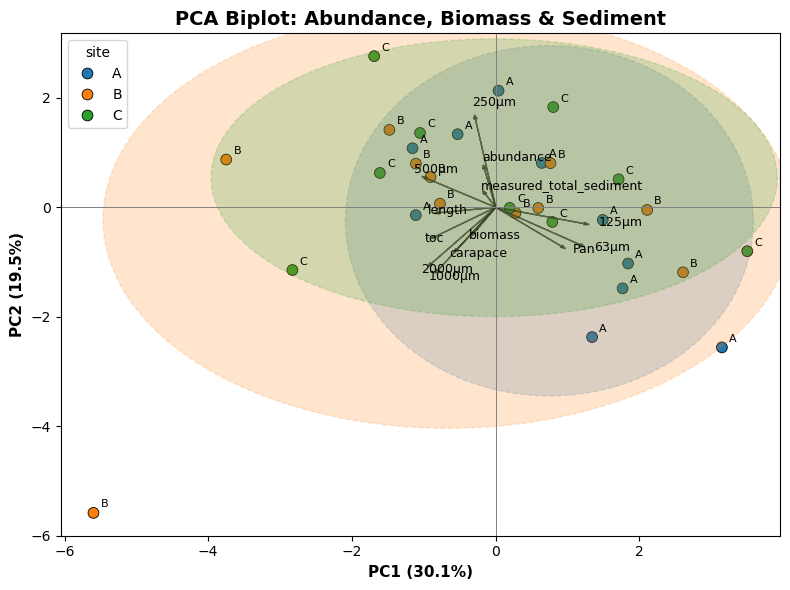

In [31]:
# Plot
plt.figure(figsize=(8, 6))

# Scatter plot of sites
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue=site_col, s=60, edgecolor="black")

# Add site labels
if label_points:
    for i, row in scores_df.iterrows():
        plt.text(row["PC1"]+0.1, row["PC2"]+0.1, str(row[site_col]), fontsize=8)

# Arrows for loadings
for _, row in loadings.iterrows():
    plt.arrow(0, 0, row["PC1"], row["PC2"], 
              color="black", alpha=0.7, head_width=0.05, length_includes_head=True)
    if label_vars:
        plt.text(row["PC1"]*1.1, row["PC2"]*1.1, row["Variable"], color="black", fontsize=9)

# Labels & theme
plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=11, fontweight="bold")
plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=11, fontweight="bold")
if title:
    plt.title(title, fontsize=14, fontweight="bold")
plt.axhline(0, color="grey", linewidth=0.7)
plt.axvline(0, color="grey", linewidth=0.7)

# Get the color palette used by seaborn
palette = sns.color_palette(n_colors=scores_df[site_col].nunique())
site_colors = dict(zip(scores_df[site_col].unique(), palette))

for site, group in scores_df.groupby(site_col):
    # Transparent ellipse per site
    ellipse = mpatches.Ellipse(
        (group["PC1"].mean(), group["PC2"].mean()),
        width=group["PC1"].std()*4,
        height=group["PC2"].std()*4,
        facecolor=site_colors[site],   # match site color
        edgecolor=site_colors[site],
        alpha=0.2,                     # transparency
        linestyle="--",
        linewidth=1
    )
    plt.gca().add_patch(ellipse)
    
plt.grid(False)
plt.tight_layout()
plt.savefig("PCA.png", dpi=500)
plt.show()

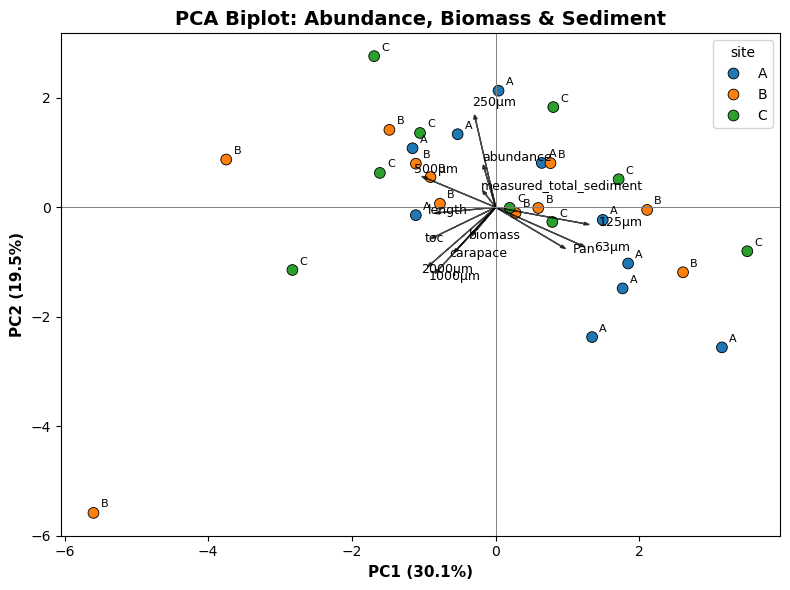

In [33]:
# Plot
plt.figure(figsize=(8, 6))

# Scatter plot of sites
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue=site_col, s=60, edgecolor="black")

# Add site labels
if label_points:
    for i, row in scores_df.iterrows():
        plt.text(row["PC1"]+0.1, row["PC2"]+0.1, str(row[site_col]), fontsize=8)

# Arrows for loadings
for _, row in loadings.iterrows():
    plt.arrow(0, 0, row["PC1"], row["PC2"], 
              color="black", alpha=0.7, head_width=0.05, length_includes_head=True)
    if label_vars:
        plt.text(row["PC1"]*1.1, row["PC2"]*1.1, row["Variable"], color="black", fontsize=9)

# Labels & theme
plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=11, fontweight="bold")
plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=11, fontweight="bold")
if title:
    plt.title(title, fontsize=14, fontweight="bold")
plt.axhline(0, color="grey", linewidth=0.7)
plt.axvline(0, color="grey", linewidth=0.7)
    
plt.grid(False)
plt.tight_layout()
plt.savefig("PCA.png", dpi=500)
plt.show()

In [42]:
loadings

,Variable,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,abundance,0.129717,1.120216,0.078300,0.416615,0.595771,-0.040726,0.497783,0.112902,0.087349,0.017219,0.214404,-0.025856,0.085440
1,biomass,-0.451023,1.517389,-0.072791,0.134492,0.049392,0.397827,-0.427513,0.379526,-0.400653,-0.062915,-0.118383,0.119827,-0.133467
2,length,-0.866712,1.252687,0.007160,0.057229,-0.297612,0.175985,-0.114153,-0.277067,0.434043,0.520936,0.203077,-0.096628,0.138434
3,carapace,-0.681060,0.813153,-0.262130,0.129296,-0.560272,-0.229113,0.401181,0.210657,0.115103,-0.435607,-0.109480,0.050313,-0.018014
4,2000µm,-1.067327,-0.473398,-0.324142,0.187277,0.212835,-0.004110,-0.167363,-0.105053,-0.036045,-0.132040,-0.314236,-0.315659,0.637888
5,1000µm,-0.965460,-0.606441,-0.377322,0.061857,0.207506,-0.093318,-0.177149,-0.039295,0.187137,-0.058105,0.310858,0.696652,-0.065761
6,500µm,-0.864560,-0.428447,0.361126,0.230529,-0.152748,0.385032,0.291983,-0.483392,-0.378846,-0.126777,-0.018665,0.247516,0.035846
7,250µm,0.218551,-0.052585,0.610717,0.045571,-0.101214,-0.040658,-0.198894,0.335492,0.285772,-0.182016,-0.000826,0.303801,0.498228
8,125µm,1.206306,0.254977,-0.173561,0.286755,-0.139000,-0.230897,0.056195,-0.092440,-0.185136,0.443453,-0.445843,0.413493,0.183638
9,63µm,1.154702,-0.276740,-0.254215,0.188816,-0.276466,0.139861,-0.047692,0.048989,-0.280193,-0.052595,0.658118,-0.102112,0.342893


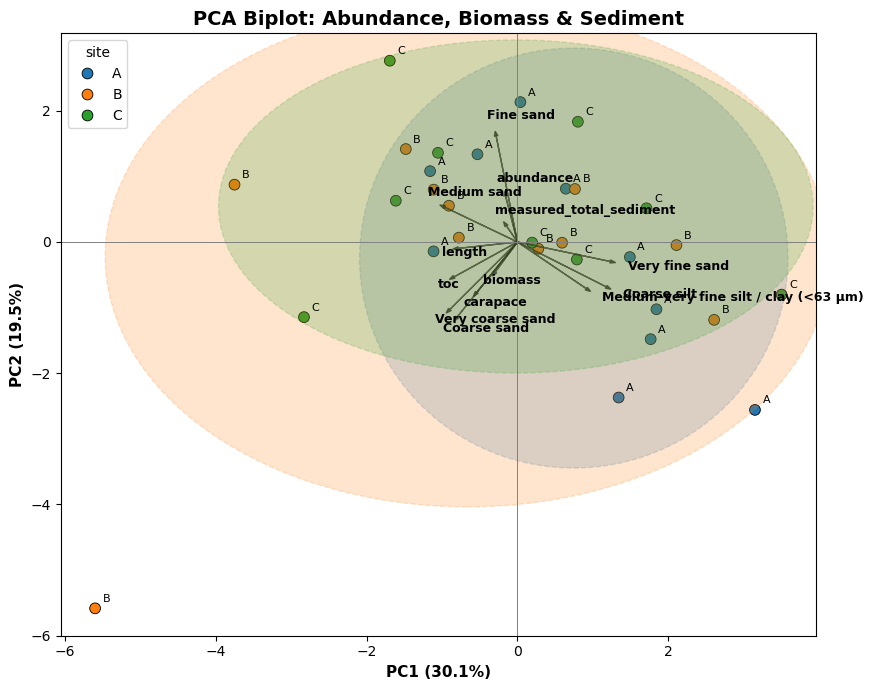

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# --- Data prep ---
X2 = merged.drop(["site","replicate","sample", "month"], axis=1).fillna(0)
X2_scaled = StandardScaler().fit_transform(X2)

# --- PCA ---
pca = PCA()
pca_result2 = pca.fit_transform(X2_scaled)

# --- Variance explained ---
pca_var_percent = [round(x*100, 1) for x in pca.explained_variance_ratio_]

# --- Scores dataframe ---
scores_df = pd.DataFrame(pca_result2, columns=[f"PC{i+1}" for i in range(pca_result2.shape[1])], index=merged.index)
scores_df[list(merged.columns)] = merged

# --- Loadings dataframe ---
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                        index=X2.columns)
loadings = loadings.reset_index().rename(columns={"index": "Variable"})

# --- Scale factor for arrows ---
scale_factor = 3
loadings["PC1"] *= scale_factor
loadings["PC2"] *= scale_factor

# --- Mapping sieve columns to descriptive sediment types ---
sieve_mapping = {
    'sieve_2mm': 'Very coarse sand',
    'sieve_1mm': 'Coarse sand',
    'sieve_500um': 'Medium sand',
    'sieve_250um': 'Fine sand',
    'sieve_125um': 'Very fine sand',
    'sieve_63um': 'Coarse silt',
    'sieve_pan': 'Medium–very fine silt / clay (<63 µm)'
}

# Replace sieve names using substring matching
def replace_sieve_names(var_name):
    for key, val in sieve_mapping.items():
        if key in var_name:  # replace any variable containing the key
            return val
    return var_name  # leave other names unchanged

loadings["Variable"] = loadings["Variable"].apply(replace_sieve_names)

# --- Plot settings ---
site_col = "site"
label_points = True
label_vars = True
title = "PCA Biplot: Abundance, Biomass & Sediment"

plt.figure(figsize=(9, 7))

# --- Scatter plot of sites ---
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue=site_col, s=60, edgecolor="black")

# --- Add site labels ---
if label_points:
    for i, row in scores_df.iterrows():
        plt.text(row["PC1"]+0.1, row["PC2"]+0.1, str(row[site_col]), fontsize=8)

# --- Arrows for loadings with smart label placement ---
for _, row in loadings.iterrows():
    plt.arrow(0, 0, row["PC1"], row["PC2"], color="black", alpha=0.7, head_width=0.05, length_includes_head=True)
    if label_vars:
        # Offset labels based on quadrant to reduce overlap
        offset_x = 0.1 if row["PC1"] >= 0 else -0.1
        offset_y = 0.1 if row["PC2"] >= 0 else -0.1
        plt.text(row["PC1"]*1.05 + offset_x, row["PC2"]*1.05 + offset_y, row["Variable"], 
                 color="black", fontsize=9, fontweight="bold")

# --- Labels & theme ---
plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=11, fontweight="bold")
plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=11, fontweight="bold")
plt.title(title, fontsize=14, fontweight="bold")
plt.axhline(0, color="grey", linewidth=0.7)
plt.axvline(0, color="grey", linewidth=0.7)

# --- Add transparent ellipses per site ---
palette = sns.color_palette(n_colors=scores_df[site_col].nunique())
site_colors = dict(zip(scores_df[site_col].unique(), palette))

for site, group in scores_df.groupby(site_col):
    ellipse = mpatches.Ellipse(
        (group["PC1"].mean(), group["PC2"].mean()),
        width=group["PC1"].std()*4,
        height=group["PC2"].std()*4,
        facecolor=site_colors[site],
        edgecolor=site_colors[site],
        alpha=0.2,
        linestyle="--",
        linewidth=1
    )
    plt.gca().add_patch(ellipse)

plt.grid(False)
plt.tight_layout()
plt.savefig("PCA_sediment_labels_final.png", dpi=500)
plt.show()


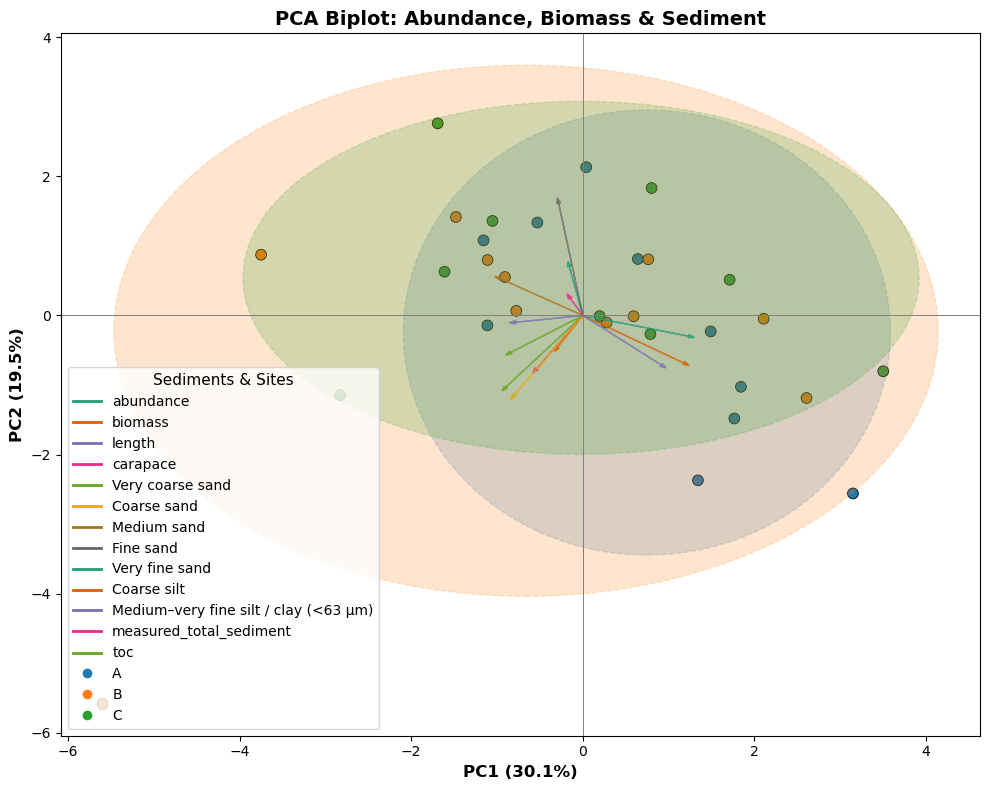

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# --- Data prep ---
X2 = merged.drop(["site","replicate","sample", "month"], axis=1).fillna(0)
X2_scaled = StandardScaler().fit_transform(X2)

# --- PCA ---
pca = PCA()
pca_result2 = pca.fit_transform(X2_scaled)

# --- Variance explained ---
pca_var_percent = [round(x*100, 1) for x in pca.explained_variance_ratio_]

# --- Scores dataframe ---
scores_df = pd.DataFrame(pca_result2, columns=[f"PC{i+1}" for i in range(pca_result2.shape[1])], index=merged.index)
scores_df[list(merged.columns)] = merged

# --- Loadings dataframe ---
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                        index=X2.columns)
loadings = loadings.reset_index().rename(columns={"index": "Variable"})

# --- Scale factor for arrows ---
scale_factor = 3
loadings["PC1"] *= scale_factor
loadings["PC2"] *= scale_factor

# --- Mapping sieve columns to descriptive sediment types ---
sieve_mapping = {
    'sieve_2mm': 'Very coarse sand',
    'sieve_1mm': 'Coarse sand',
    'sieve_500um': 'Medium sand',
    'sieve_250um': 'Fine sand',
    'sieve_125um': 'Very fine sand',
    'sieve_63um': 'Coarse silt',
    'sieve_pan': 'Medium–very fine silt / clay (<63 µm)'
}

# Replace sieve names using substring matching
def replace_sieve_names(var_name):
    for key, val in sieve_mapping.items():
        if key in var_name:
            return val
    return var_name

loadings["Variable"] = loadings["Variable"].apply(replace_sieve_names)

# --- Assign colors to sediment fractions ---
sediment_colors = sns.color_palette("Dark2", n_colors=len(loadings))
loadings["color"] = sediment_colors

# --- Plot settings ---
site_col = "site"
title = "PCA Biplot: Abundance, Biomass & Sediment"

plt.figure(figsize=(10, 8))

# --- Scatter plot of sites ---
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue=site_col, s=60, edgecolor="black")

# --- Add transparent ellipses per site ---
site_palette = sns.color_palette(n_colors=scores_df[site_col].nunique())
site_colors = dict(zip(scores_df[site_col].unique(), site_palette))

for site, group in scores_df.groupby(site_col):
    ellipse = mpatches.Ellipse(
        (group["PC1"].mean(), group["PC2"].mean()),
        width=group["PC1"].std()*4,
        height=group["PC2"].std()*4,
        facecolor=site_colors[site],
        edgecolor=site_colors[site],
        alpha=0.2,
        linestyle="--",
        linewidth=1
    )
    plt.gca().add_patch(ellipse)

# --- Draw arrows for sediment fractions (colored) ---
for _, row in loadings.iterrows():
    plt.arrow(0, 0, row["PC1"], row["PC2"], color=row["color"], alpha=0.7,
              head_width=0.05, length_includes_head=True)

# --- Labels & theme ---
plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=12, fontweight="bold")
plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=12, fontweight="bold")
plt.title(title, fontsize=14, fontweight="bold")
plt.axhline(0, color="grey", linewidth=0.7)
plt.axvline(0, color="grey", linewidth=0.7)

# --- Build legend for sediment fractions ---
legend_elements = [Line2D([0], [0], color=color, lw=2, label=var) 
                   for var, color in zip(loadings["Variable"], loadings["color"])]

# Add site markers to legend
site_elements = [Line2D([0],[0], marker='o', color='w', label=site,
                        markerfacecolor=site_colors[site], markersize=8) 
                 for site in scores_df[site_col].unique()]

plt.legend(handles=legend_elements + site_elements,
           title="Sediments & Sites", fontsize=10, title_fontsize=11, loc='best')

plt.grid(False)
plt.tight_layout()
plt.savefig("PCA_sediment_legend_final.png", dpi=500)
plt.show()


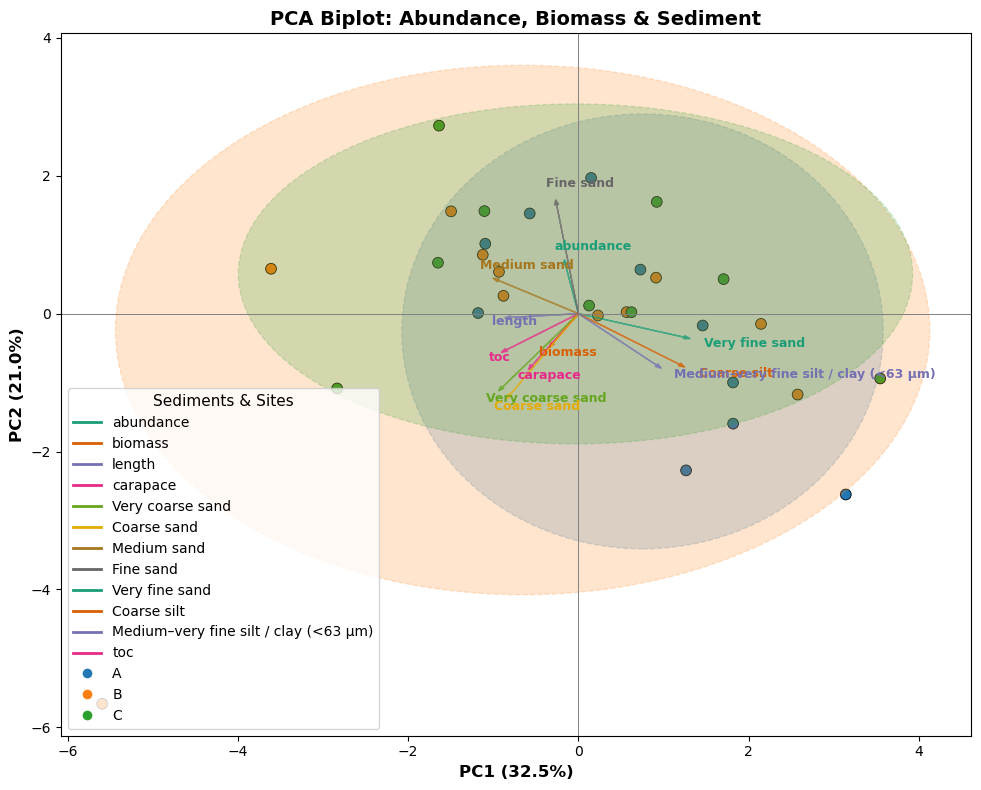

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# --- Data prep: drop metadata and fill NaNs ---
X2 = merged.drop(["site","replicate","sample", "month"], axis=1).fillna(0)

# --- Exclude measured total sediment columns ---
# Example: columns that contain 'total_sediment' or 'total'
exclude_cols = [col for col in X2.columns if 'total' in col.lower()]
X2 = X2.drop(columns=exclude_cols)

# --- Scale data ---
X2_scaled = StandardScaler().fit_transform(X2)

# --- PCA ---
pca = PCA()
pca_result2 = pca.fit_transform(X2_scaled)

# --- Variance explained ---
pca_var_percent = [round(x*100, 1) for x in pca.explained_variance_ratio_]

# --- Scores dataframe ---
scores_df = pd.DataFrame(pca_result2, columns=[f"PC{i+1}" for i in range(pca_result2.shape[1])], index=merged.index)
scores_df[list(merged.columns)] = merged

# --- Loadings dataframe ---
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                        index=X2.columns)
loadings = loadings.reset_index().rename(columns={"index": "Variable"})

# --- Scale factor for arrows ---
scale_factor = 3
loadings["PC1"] *= scale_factor
loadings["PC2"] *= scale_factor

# --- Mapping sieve columns to descriptive sediment types ---
sieve_mapping = {
    'sieve_2mm': 'Very coarse sand',
    'sieve_1mm': 'Coarse sand',
    'sieve_500um': 'Medium sand',
    'sieve_250um': 'Fine sand',
    'sieve_125um': 'Very fine sand',
    'sieve_63um': 'Coarse silt',
    'sieve_pan': 'Medium–very fine silt / clay (<63 µm)'
}

# Replace sieve names using substring matching
def replace_sieve_names(var_name):
    for key, val in sieve_mapping.items():
        if key in var_name:
            return val
    return var_name

loadings["Variable"] = loadings["Variable"].apply(replace_sieve_names)

# --- Assign colors to sediment fractions ---
sediment_colors = sns.color_palette("Dark2", n_colors=len(loadings))
loadings["color"] = sediment_colors

# --- Plot settings ---
site_col = "site"
title = "PCA Biplot: Abundance, Biomass & Sediment"

plt.figure(figsize=(10, 8))

# --- Scatter plot of sites ---
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue=site_col, s=60, edgecolor="black")

# --- Add transparent ellipses per site ---
site_palette = sns.color_palette(n_colors=scores_df[site_col].nunique())
site_colors = dict(zip(scores_df[site_col].unique(), site_palette))

for site, group in scores_df.groupby(site_col):
    ellipse = mpatches.Ellipse(
        (group["PC1"].mean(), group["PC2"].mean()),
        width=group["PC1"].std()*4,
        height=group["PC2"].std()*4,
        facecolor=site_colors[site],
        edgecolor=site_colors[site],
        alpha=0.2,
        linestyle="--",
        linewidth=1
    )
    plt.gca().add_patch(ellipse)

# --- Draw arrows for sediment fractions with labels ---
for _, row in loadings.iterrows():
    plt.arrow(0, 0, row["PC1"], row["PC2"], color=row["color"], alpha=0.7,
              head_width=0.05, length_includes_head=True)
    # Smart label offset
    offset_x = 0.1 if row["PC1"] >= 0 else -0.1
    offset_y = 0.1 if row["PC2"] >= 0 else -0.1
    plt.text(row["PC1"]*1.05 + offset_x, row["PC2"]*1.05 + offset_y, row["Variable"], 
             color=row["color"], fontsize=9, fontweight="bold")

# --- Labels & theme ---
plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=12, fontweight="bold")
plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=12, fontweight="bold")
plt.title(title, fontsize=14, fontweight="bold")
plt.axhline(0, color="grey", linewidth=0.7)
plt.axvline(0, color="grey", linewidth=0.7)

# --- Build legend ---
# Sediment fractions legend
legend_elements = [Line2D([0], [0], color=color, lw=2, label=var) 
                   for var, color in zip(loadings["Variable"], loadings["color"])]

# Site markers legend
site_elements = [Line2D([0],[0], marker='o', color='w', label=site,
                        markerfacecolor=site_colors[site], markersize=8) 
                 for site in scores_df[site_col].unique()]

plt.legend(handles=legend_elements + site_elements,
           title="Sediments & Sites", fontsize=10, title_fontsize=11, loc='best')

plt.grid(False)
plt.tight_layout()
plt.savefig("PCA_sediment_labels_legend.png", dpi=500)
plt.show()


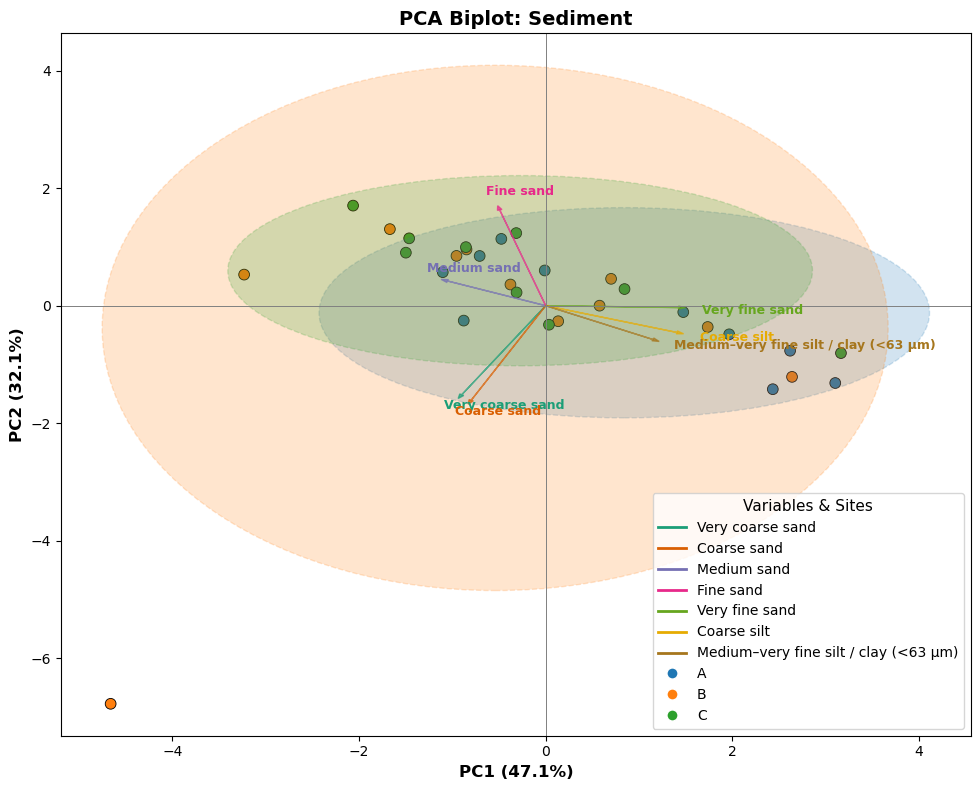

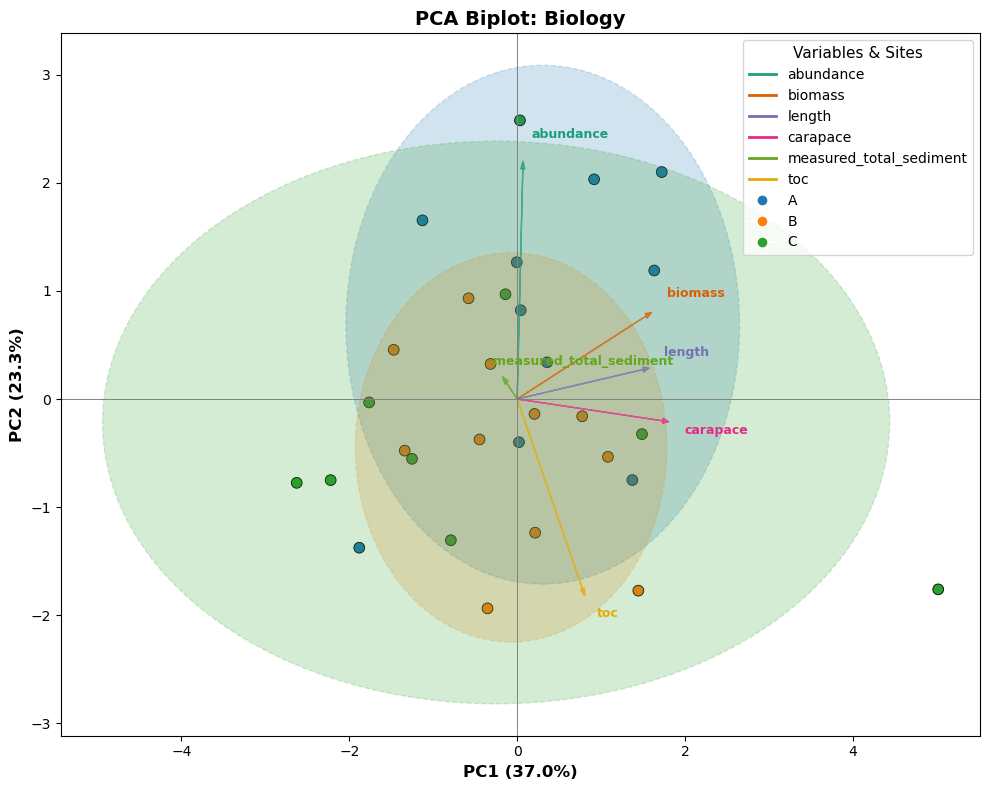

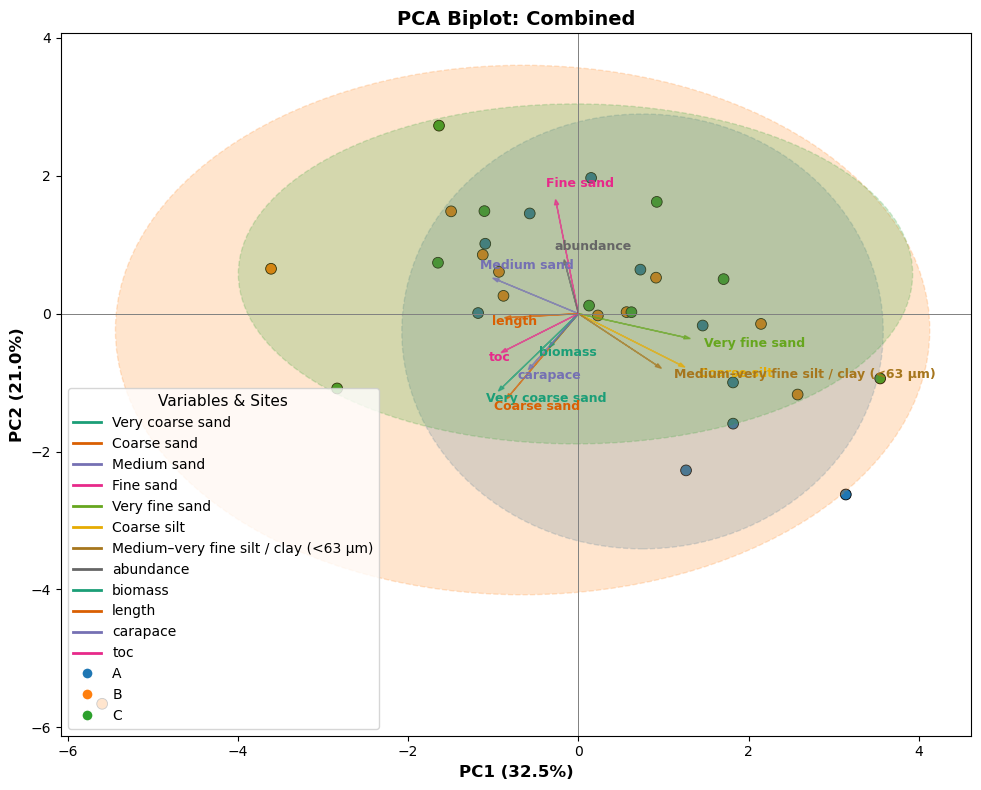

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# --- Helper function to run PCA and plot ---
def run_pca_plot(data, var_type, site_col="site", title="PCA Biplot"):
    """
    Run PCA on 'data' and plot biplot with arrows, labels, and legend.
    var_type: 'Sediment', 'Biology', 'Combined' (for legend title)
    """
    # Scale data
    X_scaled = StandardScaler().fit_transform(data)
    
    # PCA
    pca = PCA()
    pca_result = pca.fit_transform(X_scaled)
    pca_var_percent = [round(x*100, 1) for x in pca.explained_variance_ratio_]
    
    # Scores
    scores_df = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(pca_result.shape[1])], index=data.index)
    scores_df[site_col] = merged[site_col]
    
    # Loadings
    loadings = pd.DataFrame(pca.components_.T, 
                            columns=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                            index=data.columns)
    loadings = loadings.reset_index().rename(columns={"index": "Variable"})
    
    # Scale factor for arrows
    scale_factor = 3
    loadings["PC1"] *= scale_factor
    loadings["PC2"] *= scale_factor
    
    # Replace sieve names if Sediment or Combined PCA
    if var_type in ["Sediment", "Combined"]:
        sieve_mapping = {
            'sieve_2mm': 'Very coarse sand',
            'sieve_1mm': 'Coarse sand',
            'sieve_500um': 'Medium sand',
            'sieve_250um': 'Fine sand',
            'sieve_125um': 'Very fine sand',
            'sieve_63um': 'Coarse silt',
            'sieve_pan': 'Medium–very fine silt / clay (<63 µm)'
        }
        def replace_sieve_names(var_name):
            for key, val in sieve_mapping.items():
                if key in var_name:
                    return val
            return var_name
        loadings["Variable"] = loadings["Variable"].apply(replace_sieve_names)
    
    # Assign colors to variables
    var_colors = sns.color_palette("Dark2", n_colors=len(loadings))
    loadings["color"] = var_colors
    
    # --- Plot ---
    plt.figure(figsize=(10, 8))
    
    # Site scatter
    sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue=site_col, s=60, edgecolor="black")
    
    # Ellipses per site
    site_palette = sns.color_palette(n_colors=scores_df[site_col].nunique())
    site_colors = dict(zip(scores_df[site_col].unique(), site_palette))
    for site, group in scores_df.groupby(site_col):
        ellipse = mpatches.Ellipse(
            (group["PC1"].mean(), group["PC2"].mean()),
            width=group["PC1"].std()*4,
            height=group["PC2"].std()*4,
            facecolor=site_colors[site],
            edgecolor=site_colors[site],
            alpha=0.2,
            linestyle="--",
            linewidth=1
        )
        plt.gca().add_patch(ellipse)
    
    # Arrows and labels
    for _, row in loadings.iterrows():
        plt.arrow(0, 0, row["PC1"], row["PC2"], color=row["color"], alpha=0.7,
                  head_width=0.05, length_includes_head=True)
        offset_x = 0.1 if row["PC1"] >= 0 else -0.1
        offset_y = 0.1 if row["PC2"] >= 0 else -0.1
        plt.text(row["PC1"]*1.05 + offset_x, row["PC2"]*1.05 + offset_y, row["Variable"],
                 color=row["color"], fontsize=9, fontweight="bold")
    
    # Labels & theme
    plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=12, fontweight="bold")
    plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=12, fontweight="bold")
    plt.title(f"{title}: {var_type}", fontsize=14, fontweight="bold")
    plt.axhline(0, color="grey", linewidth=0.7)
    plt.axvline(0, color="grey", linewidth=0.7)
    
    # Build legend
    var_legend = [Line2D([0], [0], color=c, lw=2, label=v) for v, c in zip(loadings["Variable"], loadings["color"])]
    site_legend = [Line2D([0],[0], marker='o', color='w', label=site,
                           markerfacecolor=site_colors[site], markersize=8) for site in scores_df[site_col].unique()]
    plt.legend(handles=var_legend + site_legend, title="Variables & Sites", fontsize=10, title_fontsize=11, loc='best')
    
    plt.grid(False)
    plt.tight_layout()
    plt.show()


# --- Define variable sets ---
# 1. Sediment PCA
sediment_cols = [col for col in merged.columns if "sieve" in col]
X_sediment = merged[sediment_cols].fillna(0)

# 2. Biological PCA
bio_cols = [col for col in merged.columns if col not in ["site","replicate","sample","month"] + sediment_cols]
X_bio = merged[bio_cols].fillna(0)

# 3. Combined PCA (exclude measured total sediment)
combined_cols = sediment_cols + bio_cols
# Remove columns containing "measured_total_sediment" or "total_sediment"
combined_cols = [col for col in combined_cols if "total_sediment" not in col.lower() and "measured_total_sediment" not in col.lower()]
X_combined = merged[combined_cols].fillna(0)

# --- Run PCAs ---
run_pca_plot(X_sediment, var_type="Sediment", title="PCA Biplot")
run_pca_plot(X_bio, var_type="Biology", title="PCA Biplot")
run_pca_plot(X_combined, var_type="Combined", title="PCA Biplot")


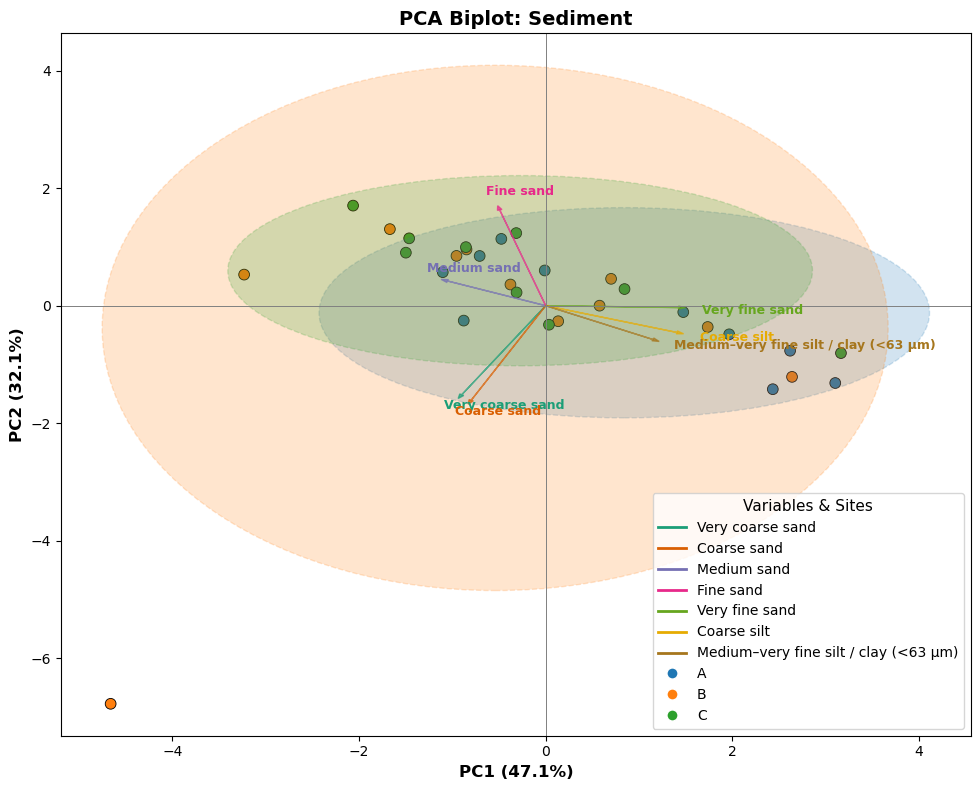

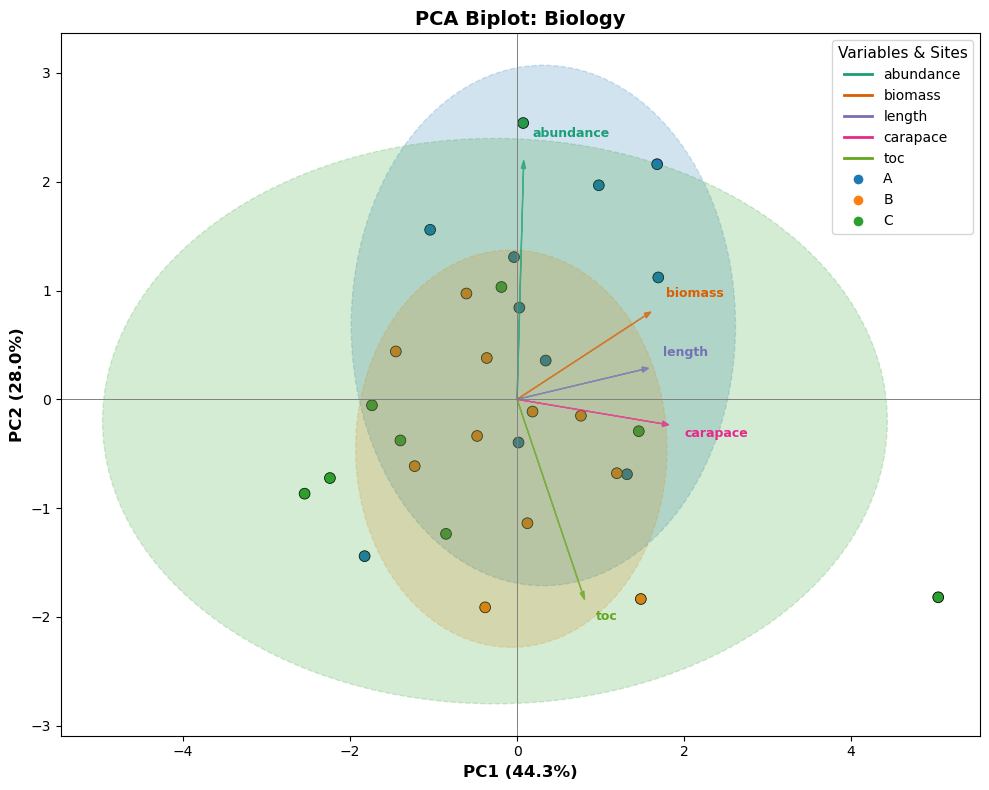

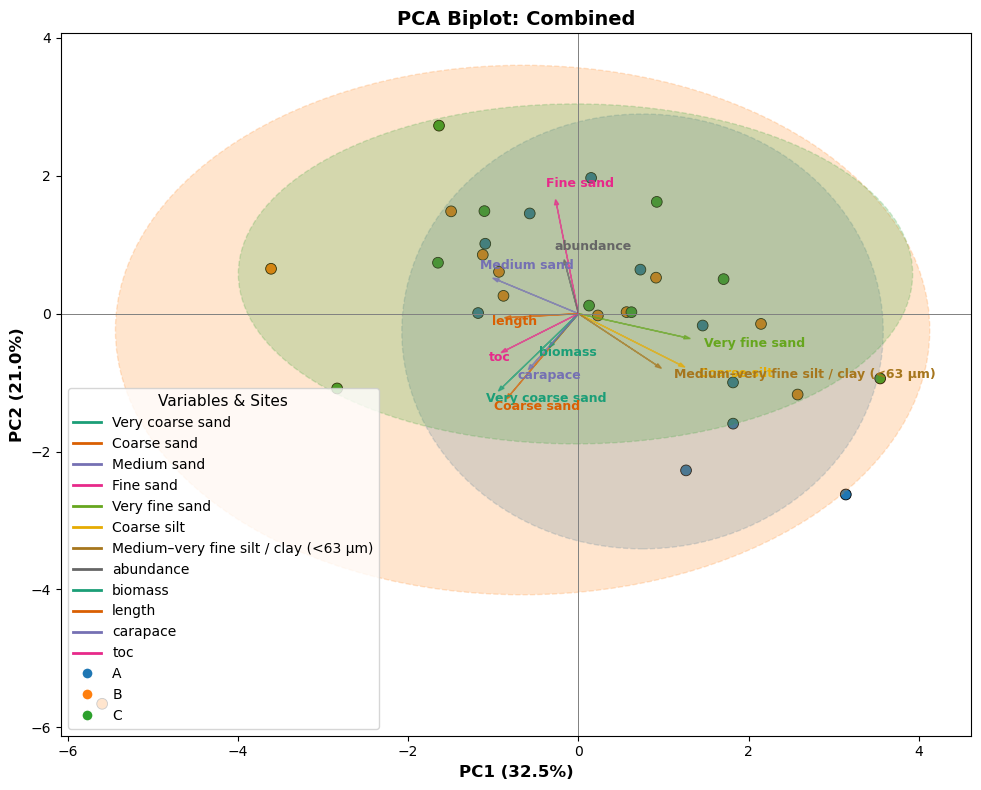

<Figure size 640x480 with 0 Axes>

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# --- Helper function to run PCA and plot ---
def run_pca_plot(data, var_type, site_col="site", title="PCA Biplot"):
    """
    Run PCA on 'data' and plot biplot with arrows, labels, and legend.
    var_type: 'Sediment', 'Biology', 'Combined' (for legend title)
    """
    # Scale data
    X_scaled = StandardScaler().fit_transform(data)
    
    # PCA
    pca = PCA()
    pca_result = pca.fit_transform(X_scaled)
    pca_var_percent = [round(x*100, 1) for x in pca.explained_variance_ratio_]
    
    # Scores
    scores_df = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(pca_result.shape[1])], index=data.index)
    scores_df[site_col] = merged[site_col]
    
    # Loadings
    loadings = pd.DataFrame(pca.components_.T, 
                            columns=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                            index=data.columns)
    loadings = loadings.reset_index().rename(columns={"index": "Variable"})
    
    # Scale factor for arrows
    scale_factor = 3
    loadings["PC1"] *= scale_factor
    loadings["PC2"] *= scale_factor
    
    # Replace sieve names if Sediment or Combined PCA
    if var_type in ["Sediment", "Combined"]:
        sieve_mapping = {
            'sieve_2mm': 'Very coarse sand',
            'sieve_1mm': 'Coarse sand',
            'sieve_500um': 'Medium sand',
            'sieve_250um': 'Fine sand',
            'sieve_125um': 'Very fine sand',
            'sieve_63um': 'Coarse silt',
            'sieve_pan': 'Medium–very fine silt / clay (<63 µm)'
        }
        def replace_sieve_names(var_name):
            for key, val in sieve_mapping.items():
                if key in var_name:
                    return val
            return var_name
        loadings["Variable"] = loadings["Variable"].apply(replace_sieve_names)
    
    # Assign colors to variables
    var_colors = sns.color_palette("Dark2", n_colors=len(loadings))
    loadings["color"] = var_colors
    
    # --- Plot ---
    plt.figure(figsize=(10, 8))
    
    # Site scatter
    sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue=site_col, s=60, edgecolor="black")
    
    # Ellipses per site
    site_palette = sns.color_palette(n_colors=scores_df[site_col].nunique())
    site_colors = dict(zip(scores_df[site_col].unique(), site_palette))
    for site, group in scores_df.groupby(site_col):
        ellipse = mpatches.Ellipse(
            (group["PC1"].mean(), group["PC2"].mean()),
            width=group["PC1"].std()*4,
            height=group["PC2"].std()*4,
            facecolor=site_colors[site],
            edgecolor=site_colors[site],
            alpha=0.2,
            linestyle="--",
            linewidth=1
        )
        plt.gca().add_patch(ellipse)
    
    # Arrows and labels
    for _, row in loadings.iterrows():
        plt.arrow(0, 0, row["PC1"], row["PC2"], color=row["color"], alpha=0.7,
                  head_width=0.05, length_includes_head=True)
        offset_x = 0.1 if row["PC1"] >= 0 else -0.1
        offset_y = 0.1 if row["PC2"] >= 0 else -0.1
        plt.text(row["PC1"]*1.05 + offset_x, row["PC2"]*1.05 + offset_y, row["Variable"],
                 color=row["color"], fontsize=9, fontweight="bold")
    
    # Labels & theme
    plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=12, fontweight="bold")
    plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=12, fontweight="bold")
    plt.title(f"{title}: {var_type}", fontsize=14, fontweight="bold")
    plt.axhline(0, color="grey", linewidth=0.7)
    plt.axvline(0, color="grey", linewidth=0.7)
    
    # Build legend
    var_legend = [Line2D([0], [0], color=c, lw=2, label=v) for v, c in zip(loadings["Variable"], loadings["color"])]
    site_legend = [Line2D([0],[0], marker='o', color='w', label=site,
                           markerfacecolor=site_colors[site], markersize=8) for site in scores_df[site_col].unique()]
    plt.legend(handles=var_legend + site_legend, title="Variables & Sites", fontsize=10, title_fontsize=11, loc='best')
    
    plt.grid(False)
    plt.tight_layout()
    plt.show()


# --- Define variable sets ---
# 1. Sediment PCA
sediment_cols = [col for col in merged.columns if "sieve" in col]
X_sediment = merged[sediment_cols].fillna(0)

# 2. Biological PCA (exclude measured_total_sediment)
bio_cols = [col for col in merged.columns if col not in ["site","replicate","sample","month"] + sediment_cols]
bio_cols = [col for col in bio_cols if "total_sediment" not in col.lower() and "measured_total_sediment" not in col.lower()]
X_bio = merged[bio_cols].fillna(0)

# 3. Combined PCA (exclude measured_total_sediment)
combined_cols = sediment_cols + bio_cols
X_combined = merged[combined_cols].fillna(0)

# --- Run PCAs ---
run_pca_plot(X_sediment, var_type="Sediment", title="PCA Biplot")
run_pca_plot(X_bio, var_type="Biology", title="PCA Biplot")
run_pca_plot(X_combined, var_type="Combined", title="PCA Biplot")

plt.tight_layout()
plt.savefig(plot_path / "PCA_Finale.png", dpi=300)
plt.show()


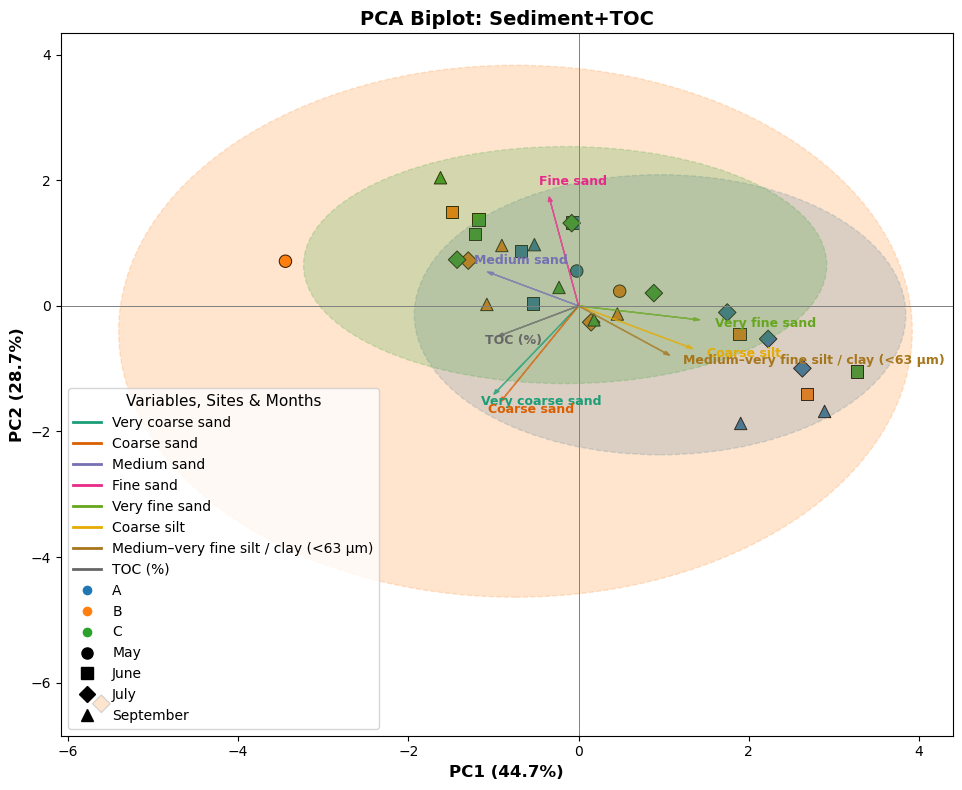

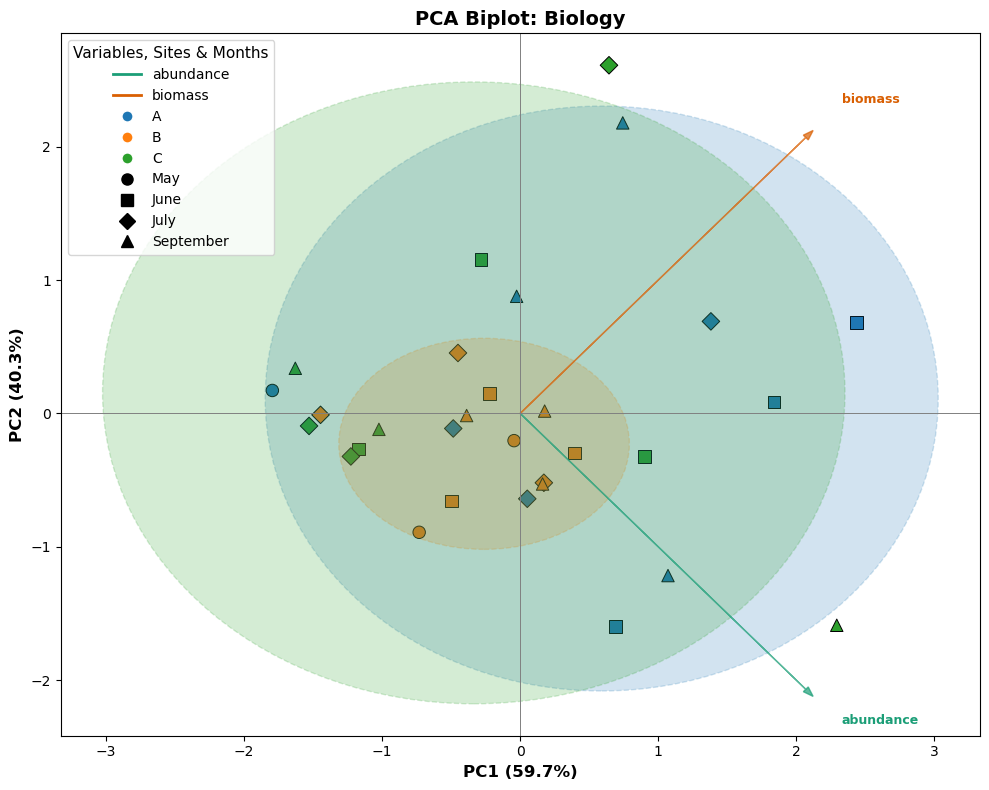

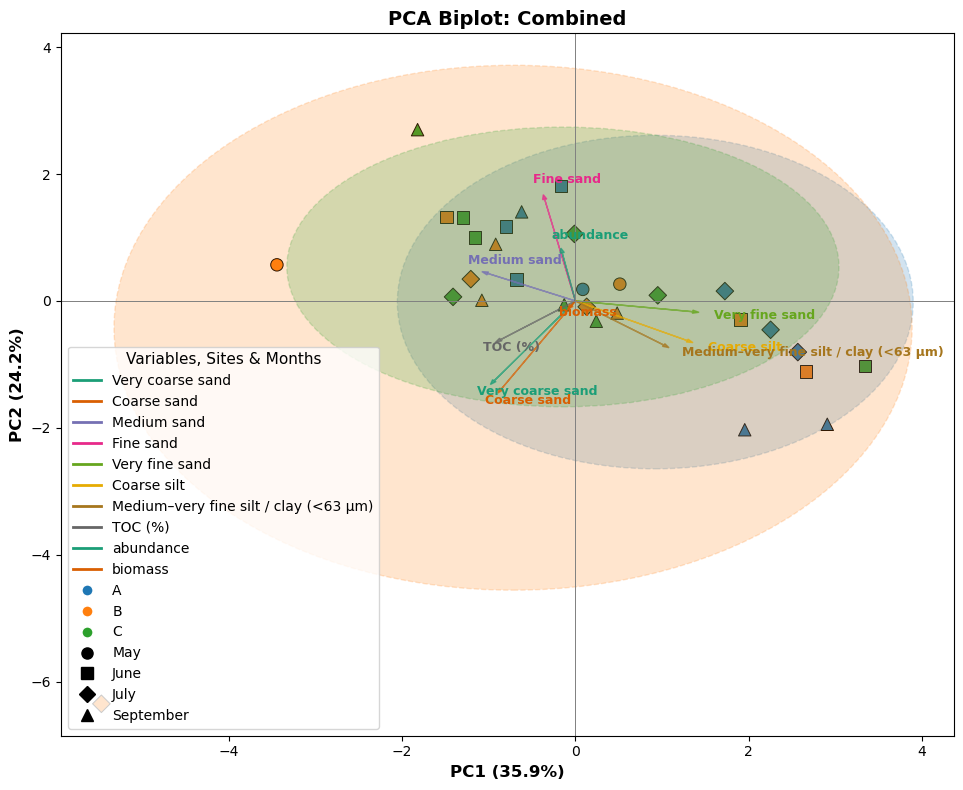

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# --- Helper function to run PCA and plot ---
def run_pca_plot(data, var_type, site_col="site", month_col="month", title="PCA Biplot"):
    """
    Run PCA on 'data' and plot biplot with arrows, labels, sites (color) and months (shape)
    var_type: 'Sediment+TOC', 'Biology', 'Combined'
    """
    # Scale data
    X_scaled = StandardScaler().fit_transform(data)
    
    # PCA
    pca = PCA()
    pca_result = pca.fit_transform(X_scaled)
    pca_var_percent = [round(x*100, 1) for x in pca.explained_variance_ratio_]
    
    # Scores dataframe
    scores_df = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(pca_result.shape[1])], index=data.index)
    scores_df[site_col] = merged[site_col]
    scores_df[month_col] = merged[month_col]
    
    # Loadings
    loadings = pd.DataFrame(pca.components_.T, 
                            columns=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                            index=data.columns)
    loadings = loadings.reset_index().rename(columns={"index": "Variable"})
    
    # Scale factor for arrows
    scale_factor = 3
    loadings["PC1"] *= scale_factor
    loadings["PC2"] *= scale_factor
    
    # Replace sieve names and TOC
    if var_type in ["Sediment+TOC", "Combined"]:
        sieve_mapping = {
            'sieve_2mm': 'Very coarse sand',
            'sieve_1mm': 'Coarse sand',
            'sieve_500um': 'Medium sand',
            'sieve_250um': 'Fine sand',
            'sieve_125um': 'Very fine sand',
            'sieve_63um': 'Coarse silt',
            'sieve_pan': 'Medium–very fine silt / clay (<63 µm)'
        }
        def replace_sieve_names(var_name):
            if var_name in sieve_mapping:
                return sieve_mapping[var_name]
            elif var_name.lower() == "toc":
                return "TOC (%)"
            else:
                return var_name
        loadings["Variable"] = loadings["Variable"].apply(replace_sieve_names)
    
    # Assign colors to variables
    var_colors = sns.color_palette("Dark2", n_colors=len(loadings))
    loadings["color"] = var_colors
    
    # --- Plot ---
    plt.figure(figsize=(10, 8))
    
    # Define markers for months
    month_shapes = {"may": "o", "june": "s", "july": "D", "september": "^"}
    
    # Scatter points
    for month, shape in month_shapes.items():
        subset = scores_df[scores_df[month_col].str.lower() == month]
        sns.scatterplot(
            data=subset,
            x="PC1", y="PC2",
            hue=site_col,
            style=month_col,
            markers=[shape],
            s=80,
            edgecolor="black",
            legend=False
        )
    
    # Ellipses per site
    site_palette = sns.color_palette(n_colors=scores_df[site_col].nunique())
    site_colors = dict(zip(scores_df[site_col].unique(), site_palette))
    for site, group in scores_df.groupby(site_col):
        ellipse = mpatches.Ellipse(
            (group["PC1"].mean(), group["PC2"].mean()),
            width=group["PC1"].std()*4,
            height=group["PC2"].std()*4,
            facecolor=site_colors[site],
            edgecolor=site_colors[site],
            alpha=0.2,
            linestyle="--",
            linewidth=1
        )
        plt.gca().add_patch(ellipse)
    
    # Arrows and labels
    for _, row in loadings.iterrows():
        plt.arrow(0, 0, row["PC1"], row["PC2"], color=row["color"], alpha=0.7,
                  head_width=0.05, length_includes_head=True)
        offset_x = 0.1 if row["PC1"] >= 0 else -0.1
        offset_y = 0.1 if row["PC2"] >= 0 else -0.1
        plt.text(row["PC1"]*1.05 + offset_x, row["PC2"]*1.05 + offset_y, row["Variable"],
                 color=row["color"], fontsize=9, fontweight="bold")
    
    # Axis labels
    plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=12, fontweight="bold")
    plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=12, fontweight="bold")
    plt.title(f"{title}: {var_type}", fontsize=14, fontweight="bold")
    plt.axhline(0, color="grey", linewidth=0.7)
    plt.axvline(0, color="grey", linewidth=0.7)
    
    # Build legend
    var_legend = [Line2D([0], [0], color=c, lw=2, label=v) for v, c in zip(loadings["Variable"], loadings["color"])]
    site_legend = [Line2D([0],[0], marker='o', color='w', label=site,
                           markerfacecolor=site_colors[site], markersize=8) for site in scores_df[site_col].unique()]
    month_legend = [Line2D([0],[0], marker=shape, color='k', label=month.capitalize(),
                            markersize=8, linestyle='') for month, shape in month_shapes.items()]
    
    plt.legend(handles=var_legend + site_legend + month_legend, title="Variables, Sites & Months",
               fontsize=10, title_fontsize=11, loc='best')
    
    plt.grid(False)
    plt.tight_layout()
    plt.show()


# --- Define variable sets ---
# 1. Sediment + TOC PCA
sediment_cols = [col for col in merged.columns if "sieve" in col]
# Check TOC column name in your dataframe
toc_col = [col for col in merged.columns if "toc" in col.lower()]  # automatically find TOC
X_sediment_toc = merged[sediment_cols + toc_col].fillna(0)

# 2. Biological PCA (Abundance, Biomass, Carapace length, Total length)
bio_cols = [col for col in merged.columns if col.lower() in ["abundance", "biomass", "carapace_length", "total_length"]]
X_bio = merged[bio_cols].fillna(0)

# 3. Combined PCA (Sediment + TOC + Biology)
combined_cols = sediment_cols + toc_col + bio_cols
X_combined = merged[combined_cols].fillna(0)

# --- Run PCAs ---
run_pca_plot(X_sediment_toc, var_type="Sediment+TOC", title="PCA Biplot")
run_pca_plot(X_bio, var_type="Biology", title="PCA Biplot")
run_pca_plot(X_combined, var_type="Combined", title="PCA Biplot")



--- PCA for may ---


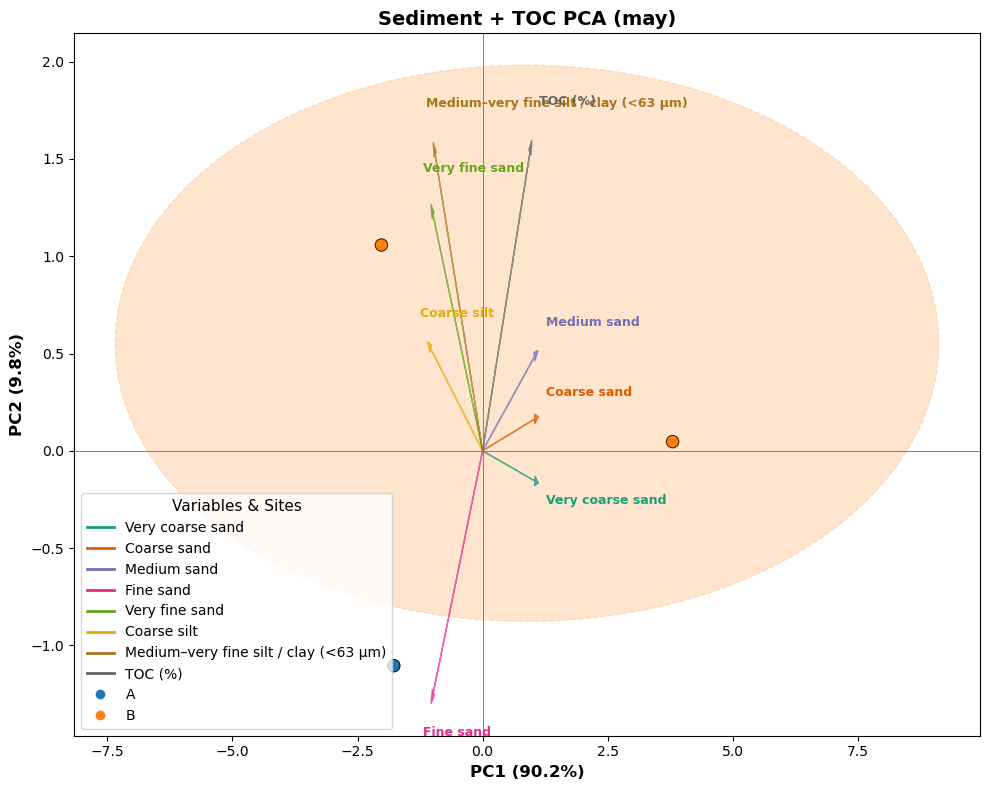

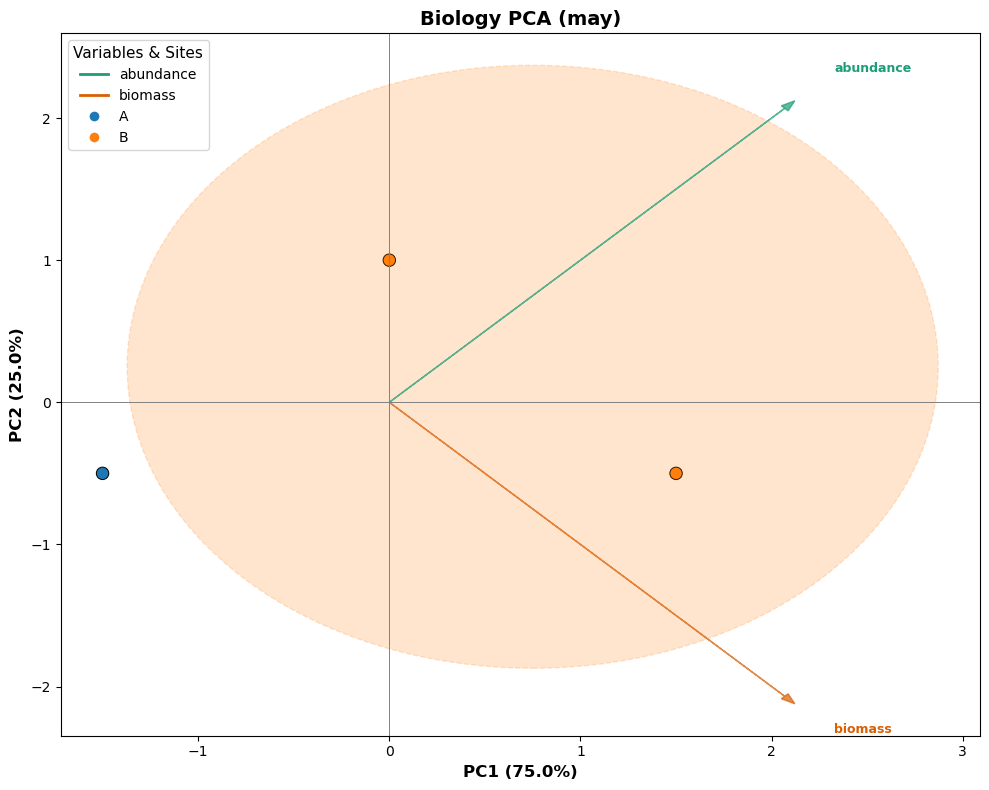

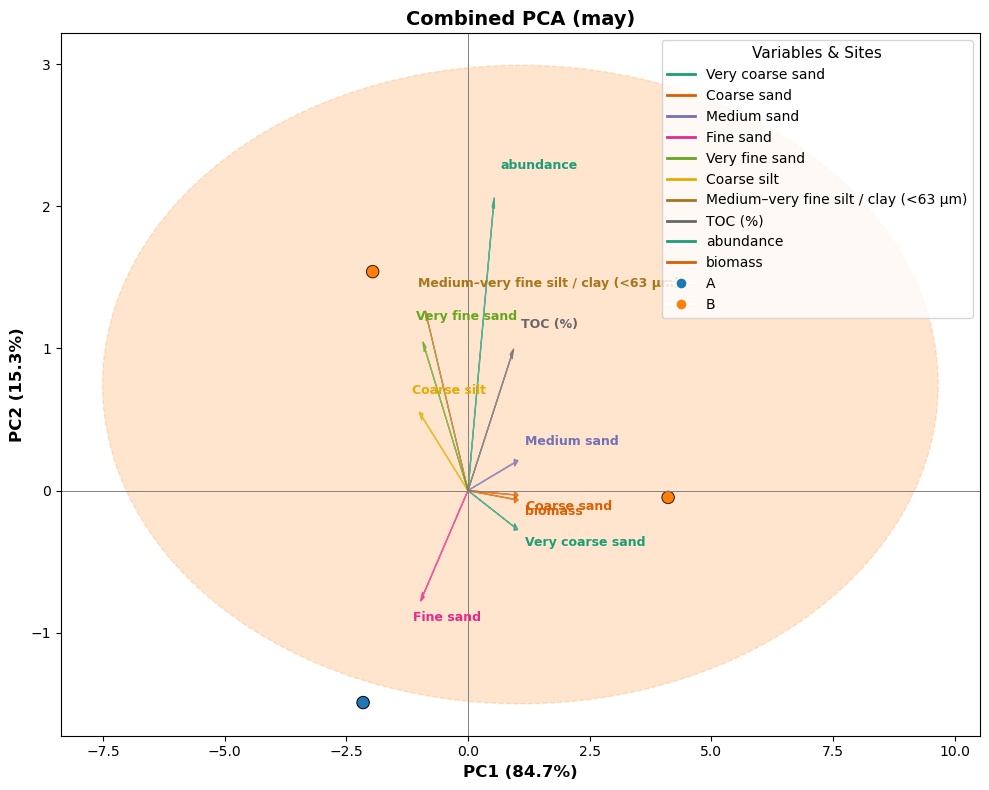


--- PCA for june ---


<Figure size 640x480 with 0 Axes>

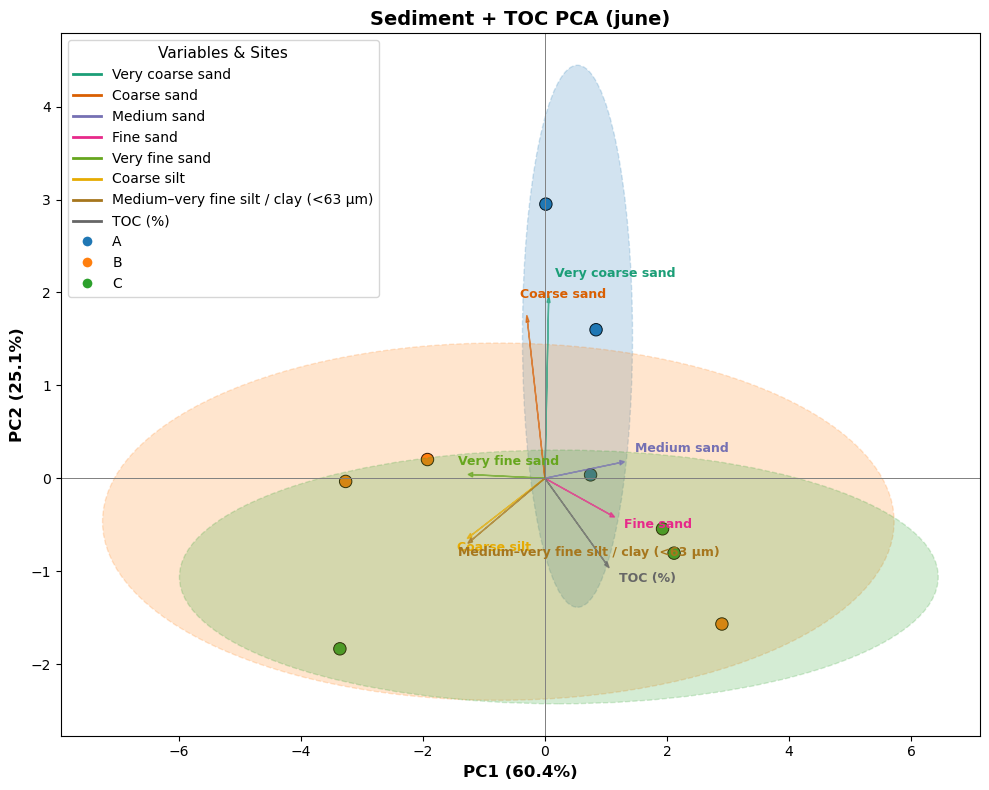

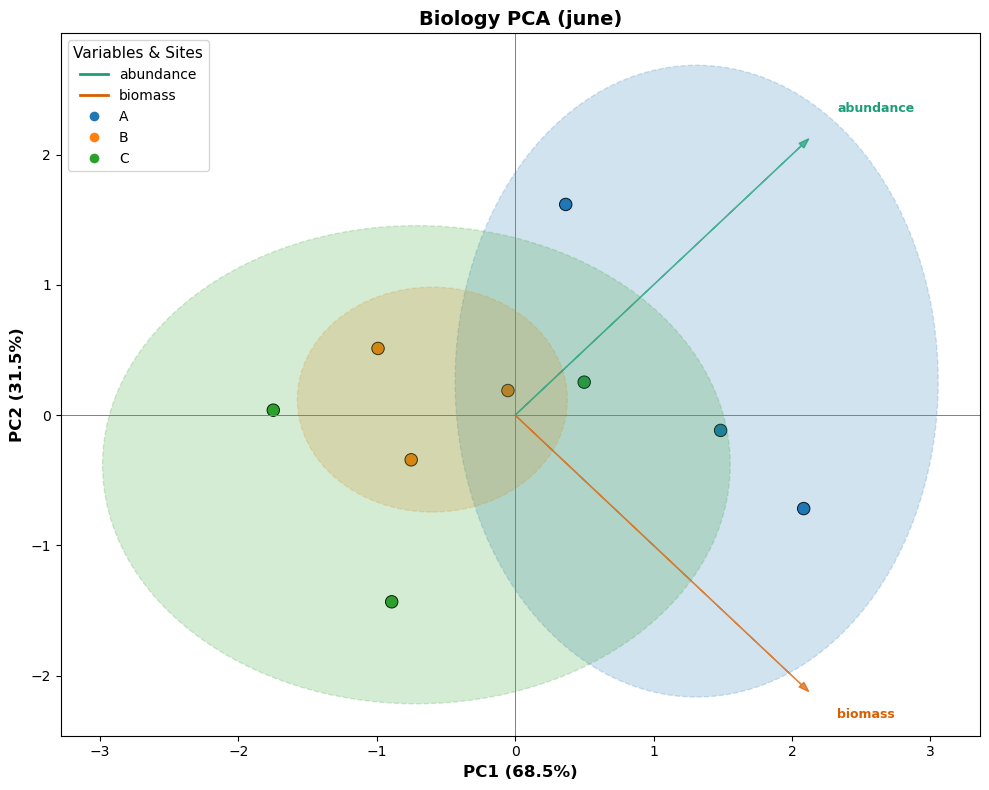

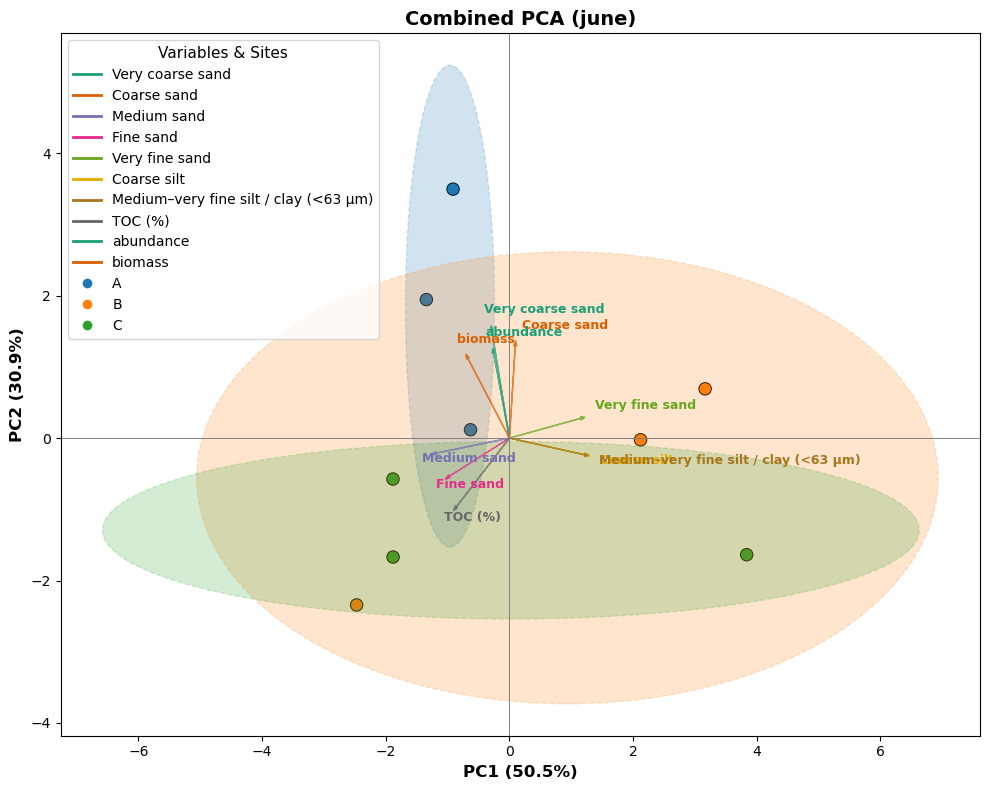


--- PCA for july ---


<Figure size 640x480 with 0 Axes>

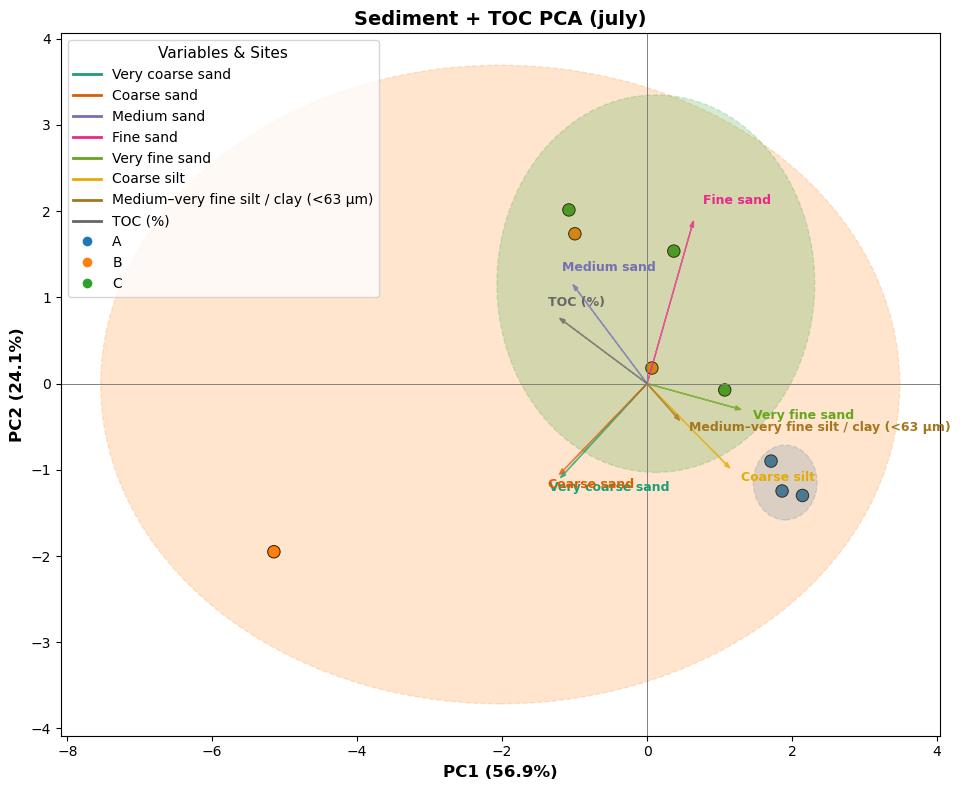

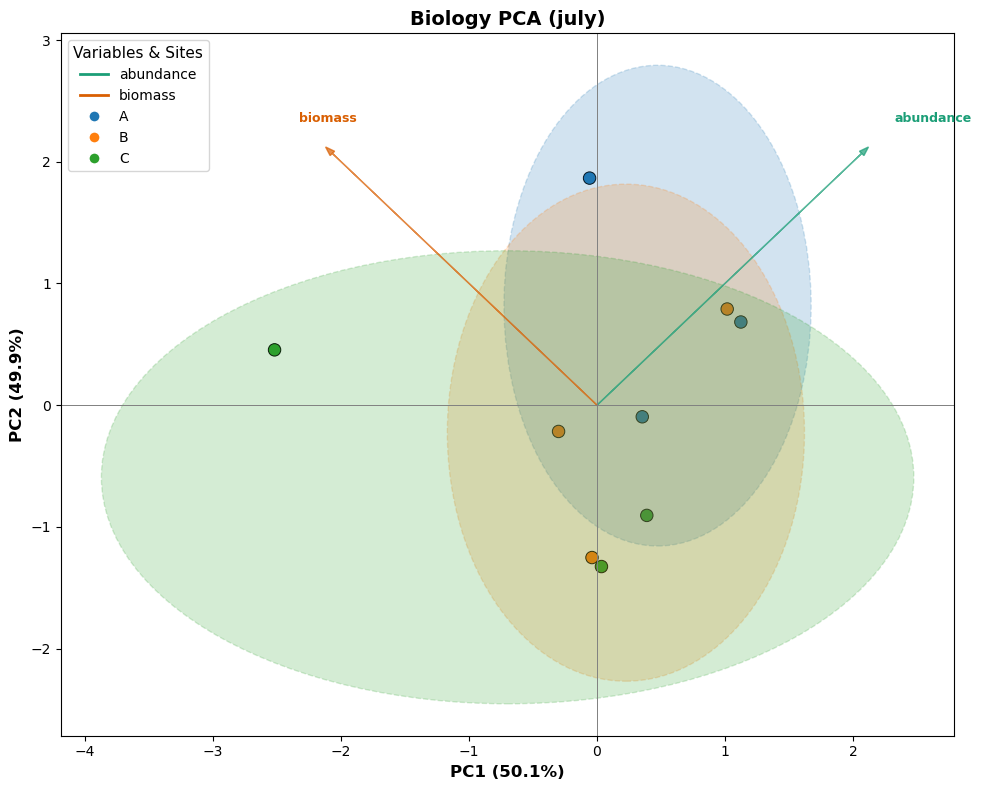

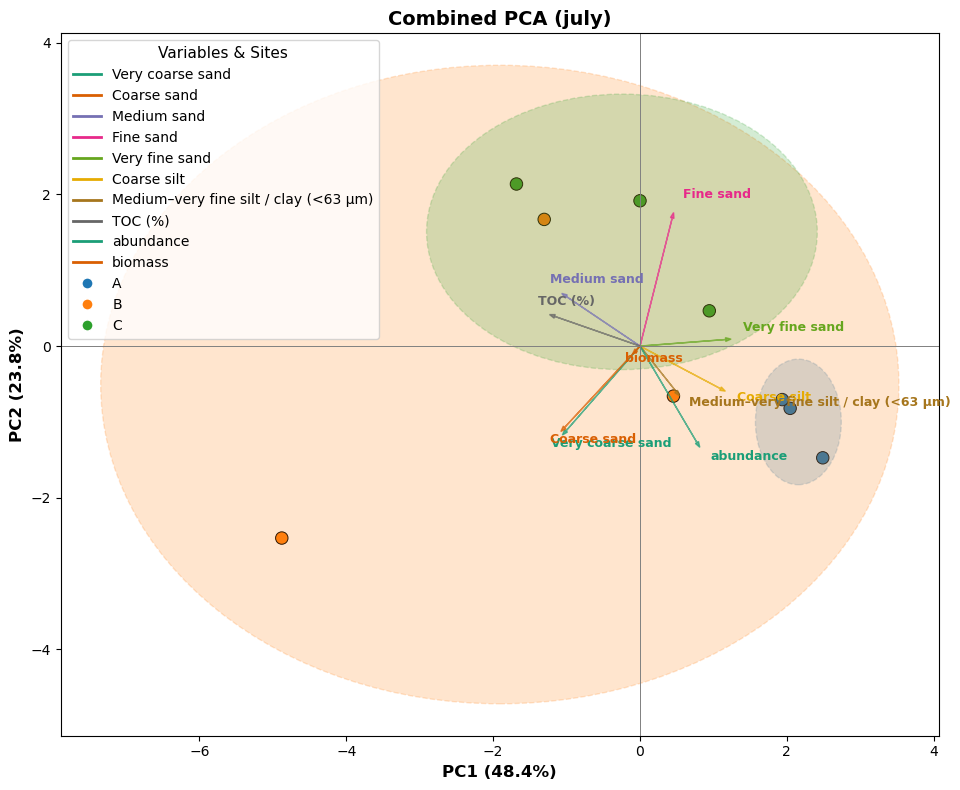


--- PCA for september ---


<Figure size 640x480 with 0 Axes>

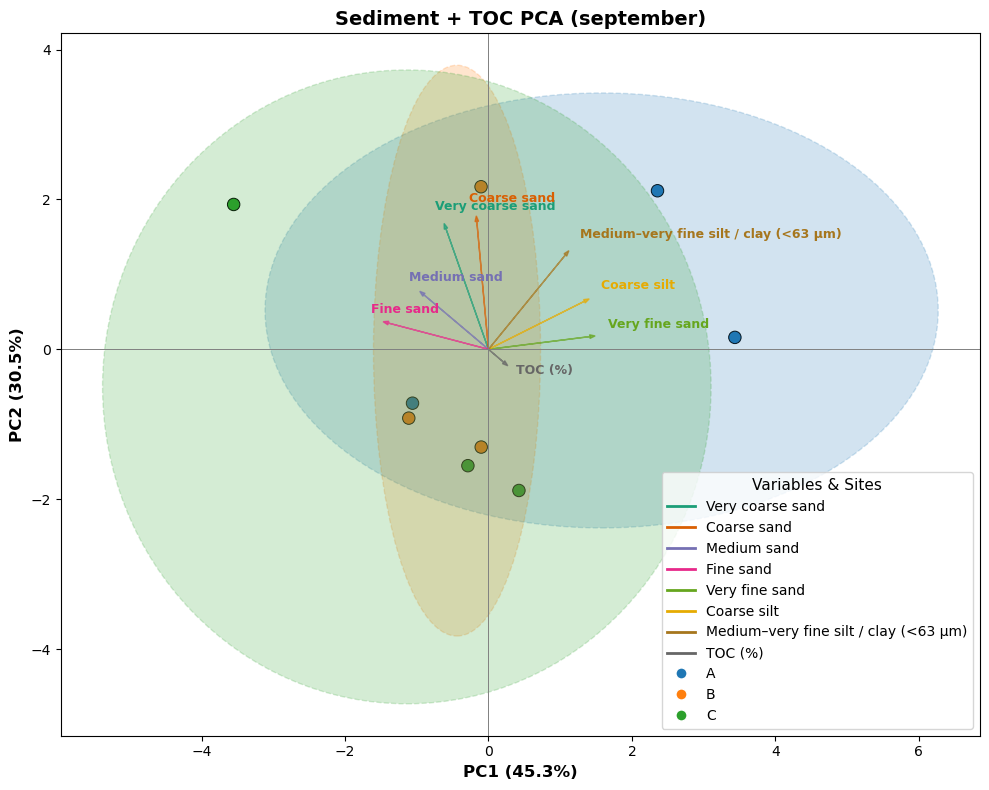

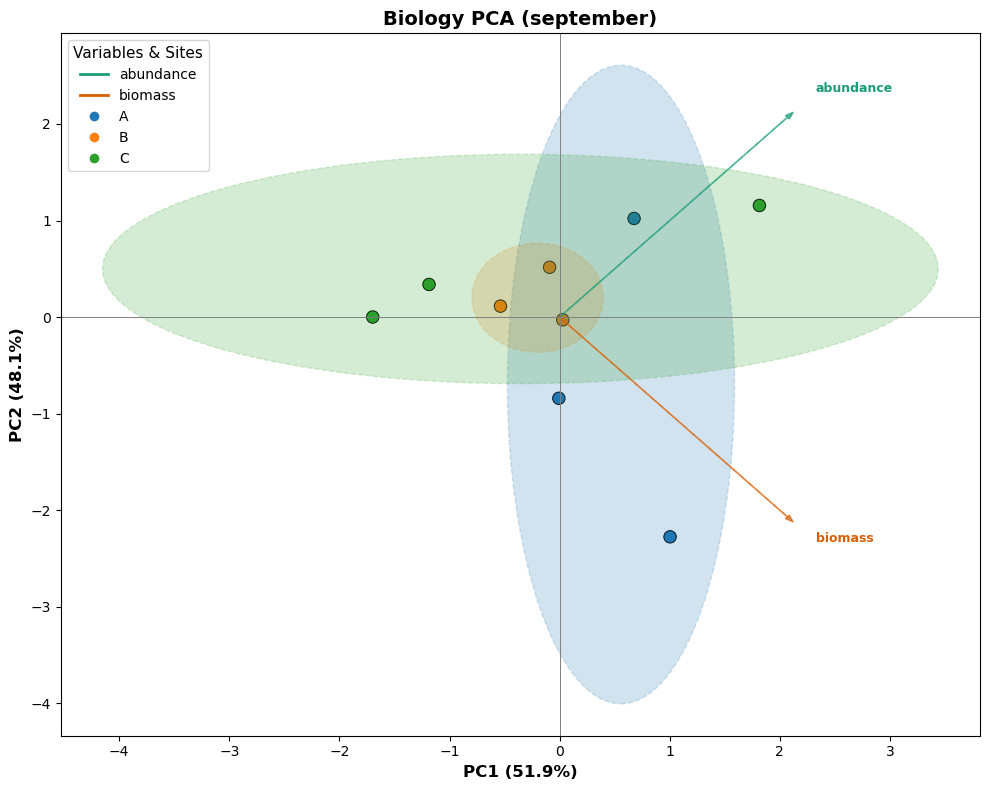

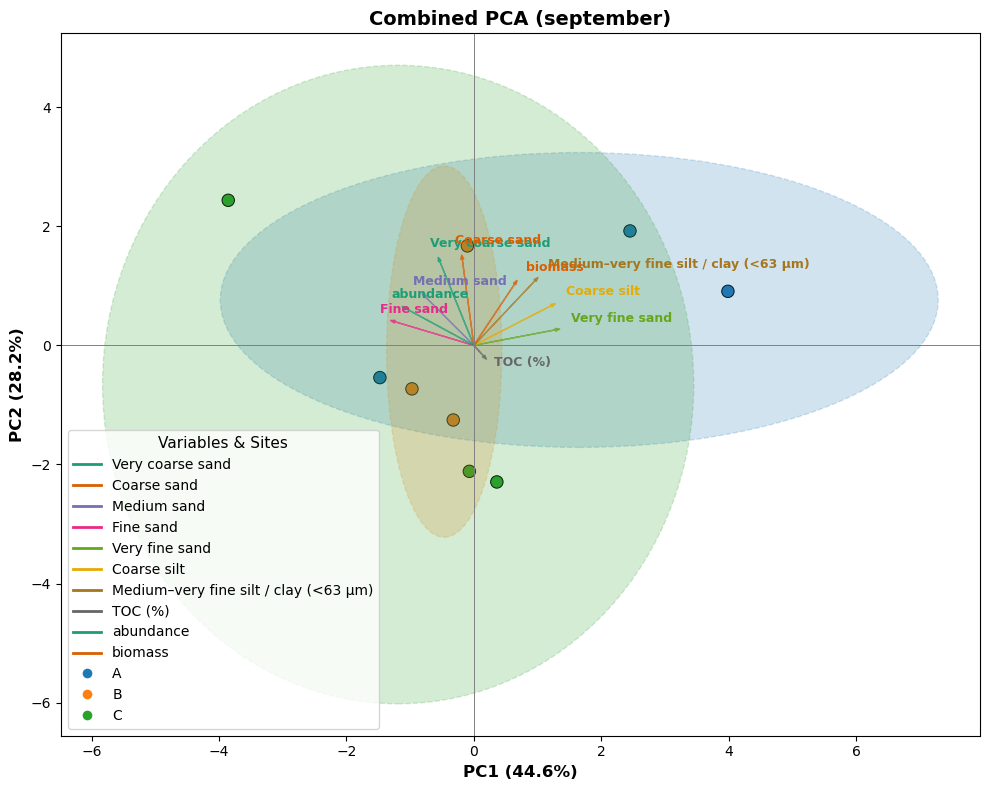

<Figure size 640x480 with 0 Axes>

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# --- Helper function to run PCA and plot ---
def run_pca_plot(data, var_type, site_col="site", title="PCA Biplot"):
    """
    Run PCA on 'data' and plot biplot with arrows, labels, and site ellipses.
    var_type: 'Sediment+TOC', 'Biology', 'Combined'
    """
    if data.shape[0] < 2:
        print(f"Not enough samples for PCA: {title}")
        return
    
    # Scale data
    X_scaled = StandardScaler().fit_transform(data)
    
    # PCA
    pca = PCA()
    pca_result = pca.fit_transform(X_scaled)
    pca_var_percent = [round(x*100, 1) for x in pca.explained_variance_ratio_]
    
    # Scores dataframe
    scores_df = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(pca_result.shape[1])], index=data.index)
    scores_df[site_col] = merged.loc[data.index, site_col]
    
    # Loadings
    loadings = pd.DataFrame(pca.components_.T, 
                            columns=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                            index=data.columns)
    loadings = loadings.reset_index().rename(columns={"index": "Variable"})
    
    # Scale factor for arrows
    scale_factor = 3
    loadings["PC1"] *= scale_factor
    loadings["PC2"] *= scale_factor
    
    # Replace sieve names and TOC
    if var_type in ["Sediment+TOC", "Combined"]:
        sieve_mapping = {
            'sieve_2mm': 'Very coarse sand',
            'sieve_1mm': 'Coarse sand',
            'sieve_500um': 'Medium sand',
            'sieve_250um': 'Fine sand',
            'sieve_125um': 'Very fine sand',
            'sieve_63um': 'Coarse silt',
            'sieve_pan': 'Medium–very fine silt / clay (<63 µm)'
        }
        def replace_sieve_names(var_name):
            if var_name in sieve_mapping:
                return sieve_mapping[var_name]
            elif var_name.lower() == "toc":
                return "TOC (%)"
            else:
                return var_name
        loadings["Variable"] = loadings["Variable"].apply(replace_sieve_names)
    
    # Assign colors to variables
    var_colors = sns.color_palette("Dark2", n_colors=len(loadings))
    loadings["color"] = var_colors
    
    # --- Plot ---
    plt.figure(figsize=(10, 8))
    
    # Scatter points
    site_palette = sns.color_palette(n_colors=scores_df[site_col].nunique())
    site_colors = dict(zip(scores_df[site_col].unique(), site_palette))
    sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue=site_col, s=80, edgecolor="black", palette=site_colors, legend=False)
    
    # Ellipses per site
    for site, group in scores_df.groupby(site_col):
        ellipse = mpatches.Ellipse(
            (group["PC1"].mean(), group["PC2"].mean()),
            width=group["PC1"].std()*4,
            height=group["PC2"].std()*4,
            facecolor=site_colors[site],
            edgecolor=site_colors[site],
            alpha=0.2,
            linestyle="--",
            linewidth=1
        )
        plt.gca().add_patch(ellipse)
    
    # Arrows and labels
    for _, row in loadings.iterrows():
        plt.arrow(0, 0, row["PC1"], row["PC2"], color=row["color"], alpha=0.7,
                  head_width=0.05, length_includes_head=True)
        offset_x = 0.1 if row["PC1"] >= 0 else -0.1
        offset_y = 0.1 if row["PC2"] >= 0 else -0.1
        plt.text(row["PC1"]*1.05 + offset_x, row["PC2"]*1.05 + offset_y, row["Variable"],
                 color=row["color"], fontsize=9, fontweight="bold")
    
    # Axis labels
    plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=12, fontweight="bold")
    plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=12, fontweight="bold")
    plt.title(f"{title}", fontsize=14, fontweight="bold")
    plt.axhline(0, color="grey", linewidth=0.7)
    plt.axvline(0, color="grey", linewidth=0.7)
    
    # Build legend
    var_legend = [Line2D([0], [0], color=c, lw=2, label=v) for v, c in zip(loadings["Variable"], loadings["color"])]
    site_legend = [Line2D([0],[0], marker='o', color='w', label=site,
                           markerfacecolor=site_colors[site], markersize=8) for site in scores_df[site_col].unique()]
    
    plt.legend(handles=var_legend + site_legend, title="Variables & Sites",
               fontsize=10, title_fontsize=11, loc='best')
    
    plt.grid(False)
    plt.tight_layout()
    plt.show()


# --- Define variable sets ---
sediment_cols = [col for col in merged.columns if "sieve" in col]
toc_col = [col for col in merged.columns if "toc" in col.lower()]  # automatically detect TOC
bio_cols = [col for col in merged.columns if col.lower() in ["abundance", "biomass", "carapace_length", "total_length"]]
combined_cols = sediment_cols + toc_col + bio_cols

# --- Loop through months ---
months = merged['month'].unique()
for month in months:
    print(f"\n--- PCA for {month} ---")
    df_month = merged[merged['month'] == month]
    
    # Sediment + TOC PCA
    run_pca_plot(df_month[sediment_cols + toc_col], var_type="Sediment+TOC", title=f"Sediment + TOC PCA ({month})")
    
    # Biology PCA
    run_pca_plot(df_month[bio_cols], var_type="Biology", title=f"Biology PCA ({month})")
    
    # Combined PCA
    run_pca_plot(df_month[combined_cols], var_type="Combined", title=f"Combined PCA ({month})")

    plt.tight_layout()
plt.savefig(plot_path / "zizipho's pca", dpi=300)
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10616\1491892633.py:71: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(


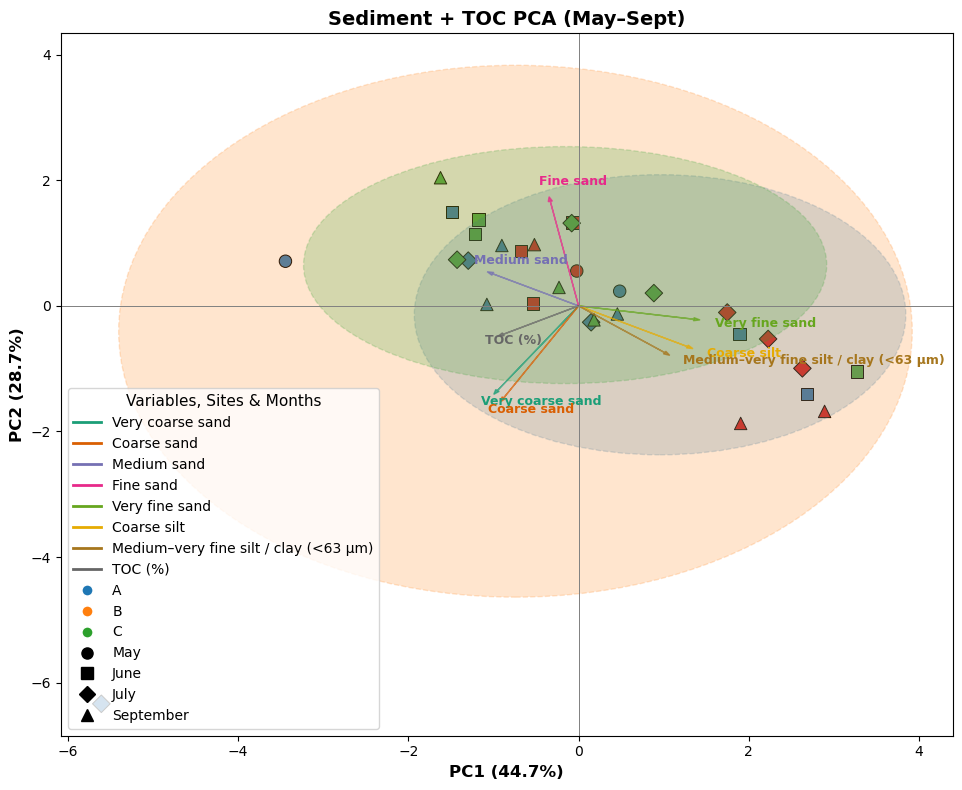

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10616\1491892633.py:71: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(


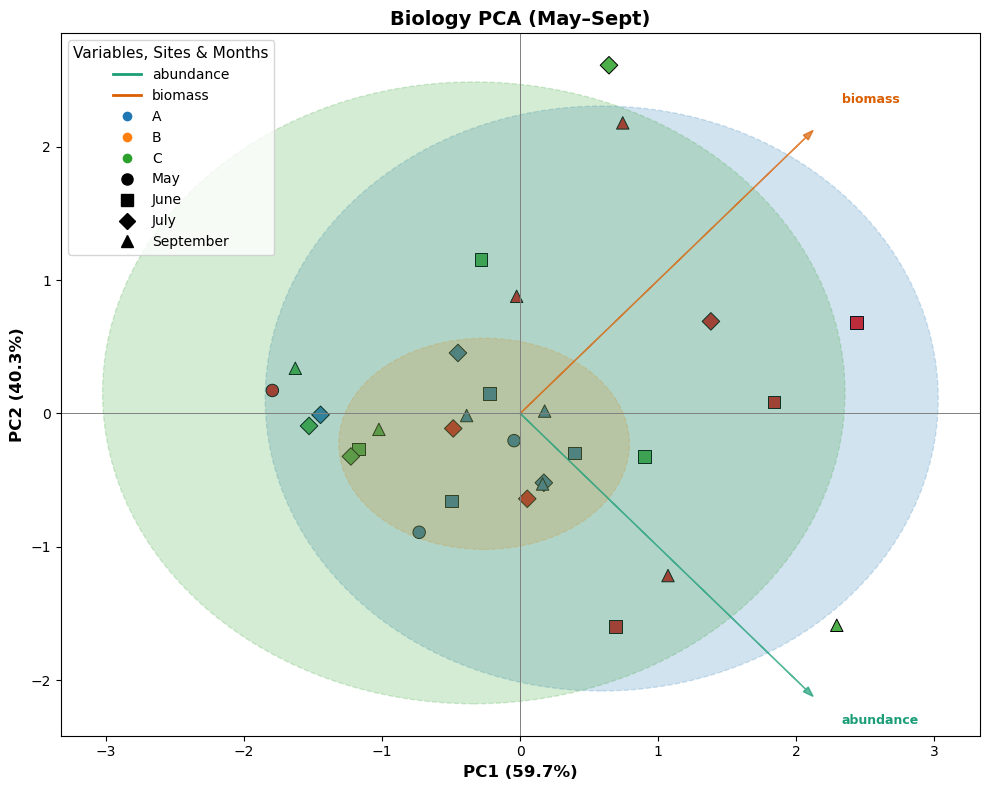

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10616\1491892633.py:71: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(


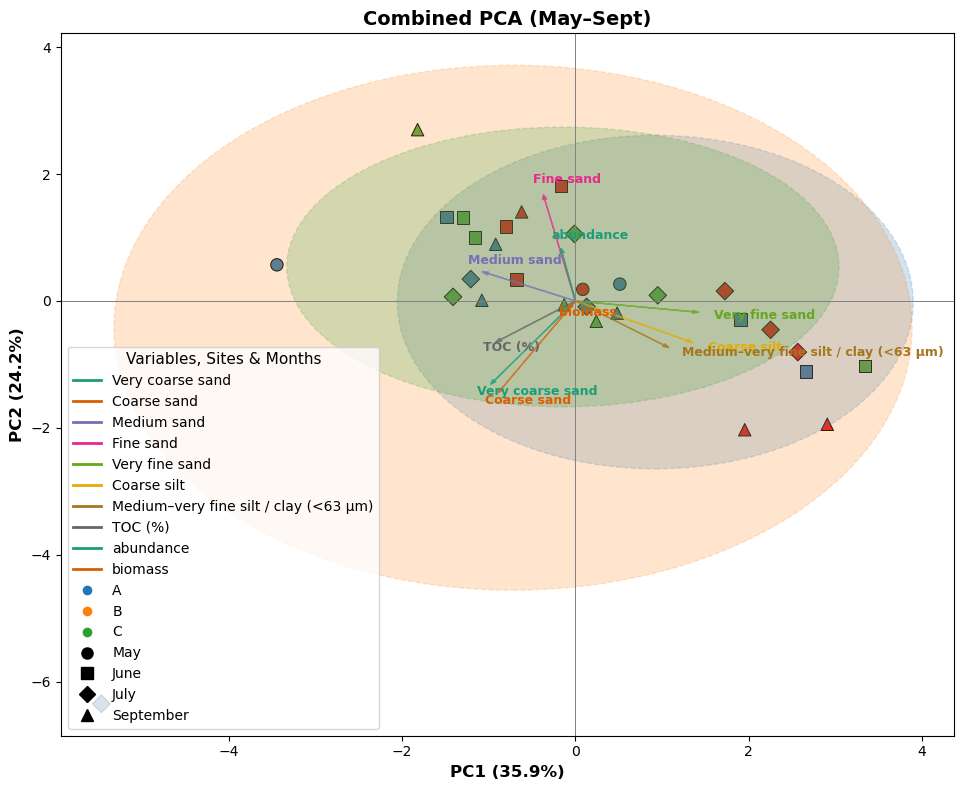

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# --- Helper function to run PCA and plot ---
def run_pca_plot(data, var_type, site_col="site", month_col="month", title="PCA Biplot"):
    """
    Run PCA on 'data' and plot biplot with arrows, labels, site colors and month shapes.
    """
    # Scale data
    X_scaled = StandardScaler().fit_transform(data)
    
    # PCA
    pca = PCA()
    pca_result = pca.fit_transform(X_scaled)
    pca_var_percent = [round(x*100, 1) for x in pca.explained_variance_ratio_]
    
    # Scores dataframe
    scores_df = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(pca_result.shape[1])], index=data.index)
    scores_df[site_col] = merged.loc[data.index, site_col]
    scores_df[month_col] = merged.loc[data.index, month_col]
    
    # Loadings
    loadings = pd.DataFrame(pca.components_.T, 
                            columns=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                            index=data.columns)
    loadings = loadings.reset_index().rename(columns={"index": "Variable"})
    
    # Scale factor for arrows
    scale_factor = 3
    loadings["PC1"] *= scale_factor
    loadings["PC2"] *= scale_factor
    
    # Replace sieve names and TOC
    sieve_mapping = {
        'sieve_2mm': 'Very coarse sand',
        'sieve_1mm': 'Coarse sand',
        'sieve_500um': 'Medium sand',
        'sieve_250um': 'Fine sand',
        'sieve_125um': 'Very fine sand',
        'sieve_63um': 'Coarse silt',
        'sieve_pan': 'Medium–very fine silt / clay (<63 µm)'
    }
    def replace_sieve_names(var_name):
        if var_name in sieve_mapping:
            return sieve_mapping[var_name]
        elif var_name.lower() == "toc":
            return "TOC (%)"
        else:
            return var_name
    loadings["Variable"] = loadings["Variable"].apply(replace_sieve_names)
    
    # Assign colors to variables
    var_colors = sns.color_palette("Dark2", n_colors=len(loadings))
    loadings["color"] = var_colors
    
    # --- Plot ---
    plt.figure(figsize=(10, 8))
    
    # Define marker shapes for months
    month_shapes = {"may": "o", "june": "s", "july": "D", "september": "^"}
    
    # Scatter points by month shape
    for month, shape in month_shapes.items():
        subset = scores_df[scores_df[month_col].str.lower() == month]
        sns.scatterplot(
            data=subset,
            x="PC1", y="PC2",
            hue=site_col,
            style=month_col,
            markers=[shape],
            s=80,
            edgecolor="black",
            palette=sns.color_palette("Set1", n_colors=scores_df[site_col].nunique()),
            legend=False
        )
    
    # Ellipses per site
    site_palette = sns.color_palette(n_colors=scores_df[site_col].nunique())
    site_colors = dict(zip(scores_df[site_col].unique(), site_palette))
    for site, group in scores_df.groupby(site_col):
        ellipse = mpatches.Ellipse(
            (group["PC1"].mean(), group["PC2"].mean()),
            width=group["PC1"].std()*4,
            height=group["PC2"].std()*4,
            facecolor=site_colors[site],
            edgecolor=site_colors[site],
            alpha=0.2,
            linestyle="--",
            linewidth=1
        )
        plt.gca().add_patch(ellipse)
    
    # Arrows and labels
    for _, row in loadings.iterrows():
        plt.arrow(0, 0, row["PC1"], row["PC2"], color=row["color"], alpha=0.7,
                  head_width=0.05, length_includes_head=True)
        offset_x = 0.1 if row["PC1"] >= 0 else -0.1
        offset_y = 0.1 if row["PC2"] >= 0 else -0.1
        plt.text(row["PC1"]*1.05 + offset_x, row["PC2"]*1.05 + offset_y, row["Variable"],
                 color=row["color"], fontsize=9, fontweight="bold")
    
    # Axis labels
    plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=12, fontweight="bold")
    plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=12, fontweight="bold")
    plt.title(f"{title}", fontsize=14, fontweight="bold")
    plt.axhline(0, color="grey", linewidth=0.7)
    plt.axvline(0, color="grey", linewidth=0.7)
    
    # Build legend
    var_legend = [Line2D([0], [0], color=c, lw=2, label=v) for v, c in zip(loadings["Variable"], loadings["color"])]
    site_legend = [Line2D([0],[0], marker='o', color='w', label=site,
                           markerfacecolor=site_colors[site], markersize=8) for site in scores_df[site_col].unique()]
    month_legend = [Line2D([0],[0], marker=shape, color='k', label=month.capitalize(),
                            markersize=8, linestyle='') for month, shape in month_shapes.items()]
    
    plt.legend(handles=var_legend + site_legend + month_legend, title="Variables, Sites & Months",
               fontsize=10, title_fontsize=11, loc='best')
    
    plt.grid(False)
    plt.tight_layout()
    plt.show()


# --- Define variable sets ---
sediment_cols = [col for col in merged.columns if "sieve" in col]
toc_col = [col for col in merged.columns if "toc" in col.lower()]  # detect TOC
bio_cols = [col for col in merged.columns if col.lower() in ["abundance", "biomass", "carapace_length", "total_length"]]
combined_cols = sediment_cols + toc_col + bio_cols

# --- PCA Plots for all months combined ---
# 1. Sediment + TOC PCA
run_pca_plot(merged[sediment_cols + toc_col], var_type="Sediment+TOC", title="Sediment + TOC PCA (May–Sept)")

# 2. Biology PCA
run_pca_plot(merged[bio_cols], var_type="Biology", title="Biology PCA (May–Sept)")

# 3. Combined PCA
run_pca_plot(merged[combined_cols], var_type="Combined", title="Combined PCA (May–Sept)")
